In this notebook, we will be working through [Building makemore Part 4: Becoming a Backprop Ninja](https://www.youtube.com/watch?v=q8SA3rM6ckI&t=5204s) by Andrej Karpathy. This is the fifth video in the "Neural Networks: Zero to Hero" series.

The core idea of this lesson: up until now we've been calling `loss.backward()` and letting PyTorch compute all gradients for us via autograd. In this notebook, we **manually derive and implement every gradient** in the backward pass — from the loss all the way back to the embedding table. This forces us to understand exactly what autograd is doing under the hood, and builds the kind of low-level intuition that becomes critical when debugging training issues, implementing custom layers, or reading research papers that describe novel architectures.

Karpathy calls this "becoming a backprop ninja" — the goal is to be so comfortable with the chain rule and tensor shapes that you can backpropagate through any computation graph by hand.

**Notebook structure:**

1. **Setup** — boilerplate, dataset, parameter initialization
2. **Atomic forward pass** — every operation broken into its smallest step
3. **Theory** — 10 numbered rules (Rules 1–10) covering chain rule, matrix derivatives, broadcasting, collapsing, and selection
4. **Exercise 1** — manual backward pass through every variable, referencing the theory rules at each step


In [1]:
# lets copy over boiler plate code from before

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
%matplotlib inline

In [2]:
# lets copy over some stuff from the previous notebook

# utility to read dataset
DATASET_PATH = '../names.txt'
SPECIAL_TOKEN = "."
block_size = 3
g = torch.Generator().manual_seed(2147483647)

def get_dataset():
    with open(DATASET_PATH, 'r') as f:
        rows = [row.strip() for row in f.readlines()]
    return rows

# Load dataset
words = get_dataset()
print(f"{len(words)} names loaded")
print(f"Examples: {words[:8]}")

# Build character mappings — identical to lesson 2
# '.' is our special start/end token at index 0, then a=1, b=2, ..., z=26
all_characters = [SPECIAL_TOKEN] + sorted(list(set(''.join(words))))
stoi = {s: i for i, s in enumerate(all_characters)}
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(f"Vocabulary size: {vocab_size}")
print(f"Mappings: {itos}")


32033 names loaded
Examples: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
Vocabulary size: 27
Mappings: {0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}


In [3]:
def build_dataset(words, block_size=3):
    """
    Convert a list of words into (X, Y) tensors for training.

    X shape: (N, block_size) — each row is a context window of character indices
    Y shape: (N,) — each element is the target character index

    This function will be called three times: once each for train, val, and test splits.
    """
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + SPECIAL_TOKEN:
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)

# 80/10/10 split at the word level
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1], block_size=3)     # training
Xdev, Ydev = build_dataset(words[n1:n2], block_size=3)  # validation ("dev" set)
Xte, Yte = build_dataset(words[n2:], block_size=3)      # test


print(f"Training:   {Xtr.shape[0]:>7,} examples from {n1:,} names")
print(f"Validation: {Xdev.shape[0]:>7,} examples from {n2-n1:,} names")
print(f"Test:       {Xte.shape[0]:>7,} examples from {len(words)-n2:,} names")

Training:   182,625 examples from 25,626 names
Validation:  22,655 examples from 3,203 names
Test:        22,866 examples from 3,204 names


# Section 1: Atomic Forward Pass and Manual Backpropagation

We are making a few changes to `get_params` compared to the previous lesson. Recall that when we have a batchnorm layer after a linear layer, the bias in the linear layer is redundant — batchnorm subtracts the mean anyway, so the bias gets cancelled out. In the previous notebook we removed it. Similarly, we had initialized `bngain` to ones and `bnbias` to zeros (their mathematically "neutral" values).

However, for this notebook we **intentionally keep the bias and initialize all parameters to small random non-zero values**. Why? Because we want every parameter to have a non-trivial gradient so we can verify our manual backprop against PyTorch's autograd. If a parameter were initialized to zero or effectively cancelled out, its gradient might be trivially zero, which wouldn't test our implementation.

After the forward pass setup, we cover a **Theory section** with 10 numbered rules (chain rule, matrix derivatives, broadcasting, collapsing, selection) that provide the toolkit for the exercises.


In [4]:
def get_params(embed_dim, block_size, n_hidden):

    tanh_gain = 5./3  # correction factor for tanh squashing variance

    g = torch.Generator().manual_seed(2147483647)
    C  = torch.randn((vocab_size, embed_dim),            generator=g)
    W1 = torch.randn((embed_dim * block_size, n_hidden), generator=g) * (tanh_gain / (embed_dim * block_size) ** 0.5)
    b1 = torch.randn(n_hidden,                        generator=g) * 0.1
    W2 = torch.randn((n_hidden, vocab_size),           generator=g) * 0.1
    b2 = torch.randn(vocab_size,                       generator=g) * 0.1

    bngain = torch.randn((1, n_hidden))*0.1 + 1.0
    bnbias = torch.randn((1, n_hidden))*0.1

    # Ignore tracking for this excercise since these are not trainable and wont be part of backprop
    # bnstd_running = torch.ones((1, n_hidden))
    # bnmean_running = torch.zeros((1, n_hidden))

    parameters = [C, W1, b1, W2, b2, bngain, bnbias]
    for p in parameters:
        p.requires_grad = True

    return parameters

Now, at the end of one of previous lesson's [notebook](../lesson_4_makemore_batchnorm/makemore_initialization_batchnorm_part1.ipynb#solution-2-running-average-exponential-moving-average), we had seen this forward and backward pass (essentially before we pytorchyfied our code)

```python
ixds = torch.randint(0, Xtr.shape[0], (batch_size,))
mini_batch_inp, mini_batch_target = Xtr[ixds], Ytr[ixds]

# Forward pass
emb = C[mini_batch_inp]                                        # (32, 3, 10)
emb_cat = emb.view(emb.shape[0], -1)                            # (32, 30)
hidden_layer_preactivation = emb_cat @ W1 + b1                  # (32, 200)

# CONVERT hidden_layer_preactivation to unit gaussian
_mean = hidden_layer_preactivation.mean(axis=0, keepdim=True) # (1, 200) take mean across the samples in the mini batch
_std = hidden_layer_preactivation.std(axis=0, keepdim=True) # (1, 200) take std across the samples in the mini batch

hidden_layer_preactivation = (hidden_layer_preactivation - _mean) / _std # convert to unit gaussian

# move the running average slightly based on the currnet mean and std directions
with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * _mean
    bnstd_running = 0.999 * bnstd_running + 0.001 * _std

# scale and shift
hidden_layer_preactivation = hidden_layer_preactivation*bngain + bnbias

h = torch.tanh(hidden_layer_preactivation)  # (32, 200)
logits = h @ W2 + b2                                           # (32, 27)
loss = F.cross_entropy(logits, mini_batch_target)

# Backward pass
for p in parameters:
    p.grad = None
loss.backward()

# Learning rate step decay: 0.1 for first 100K steps, then 0.01
lr = 0.1 if i < 100000 else 0.01
for p in parameters:
    p.data += -lr * p.grad
```

In the code above, `.backward()` does everything for us — but we have no idea _what_ it's computing inside each of those high-level operations. The goal now is to decompose every step into atomic operations and manually derive each gradient, so we truly understand what autograd is doing. This is the difference between _using_ backprop and _understanding_ backprop.


In [5]:
# Utility to compare our hand-derived gradients against PyTorch's autograd ground truth.
# dt = our manual gradient, t = the tensor whose .grad was set by loss.backward()

def cmp(s, dt, t):
    """
    We will use this to compare our calculation of gradient (dt) to pytorch's calculations (t)
    """

    exact = torch.all(dt == t.grad).item()
    approx = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()

    print(f'{s:15s} | exact: {str(exact):5s} | approximate: {str(approx):5s} | maxdiff: {maxdiff}')

In [6]:
# Lets get our parameters first, and create a single forward pass to step through

embed_dim = 10
n_hidden = 64

n = batch_size = 32
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

C, W1, b1, W2, b2, bngain, bnbias = get_params(embed_dim, block_size, n_hidden)

max_name = 12   # length of the longest name ("bngain.shape" / "bnbias.shape")

# for x in [Xb, Yb, C, W1, b1, W2, b2, bngain, bnbias]:
print(f"{'Xb.shape':<{max_name}} = {Xb.shape!s:>25}")
print(f"{'Yb.shape':<{max_name}} = {Yb.shape!s:>25}")
print(f"{'C.shape':<{max_name}} = {C.shape!s:>25}")
print(f"{'W1.shape':<{max_name}} = {W1.shape!s:>25}")
print(f"{'b1.shape':<{max_name}} = {b1.shape!s:>25}")
print(f"{'W2.shape':<{max_name}} = {W2.shape!s:>25}")
print(f"{'b2.shape':<{max_name}} = {b2.shape!s:>25}")
print(f"{'bngain.shape':<{max_name}} = {bngain.shape!s:>25}")
print(f"{'bnbias.shape':<{max_name}} = {bnbias.shape!s:>25}")

Xb.shape     =       torch.Size([32, 3])
Yb.shape     =          torch.Size([32])
C.shape      =      torch.Size([27, 10])
W1.shape     =      torch.Size([30, 64])
b1.shape     =          torch.Size([64])
W2.shape     =      torch.Size([64, 27])
b2.shape     =          torch.Size([27])
bngain.shape =       torch.Size([1, 64])
bnbias.shape =       torch.Size([1, 64])


In [7]:
parameters = [C, W1, b1, W2, b2, bngain, bnbias]

### The Atomic Forward Pass

Below we break the forward pass into the **smallest possible steps** — each line is a single arithmetic operation on tensors. In the previous notebook we wrote things like `F.cross_entropy(logits, targets)`, which internally does subtract-max, exponentiate, sum, divide, log, and index — all in one call. Here we do each of those steps explicitly so we have a named intermediate tensor for every node in the computation graph.

**Variable naming convention** (matching Karpathy's video):

- **`emb` / `embcat`**: embedding lookup and flattened (concatenated) embedding
- **`hprebn`**: hidden layer pre-batchnorm (output of linear layer 1)
- **`bnmeani`, `bndiff`, `bndiff2`, `bnvar`, `bnvar_inv`, `bnraw`**: the individual steps of batch normalization — mean, centered values, squared differences, variance, inverse std, and the normalized output
- **`hpreact`**: hidden layer pre-activation (after batchnorm scale+shift, before tanh)
- **`h`**: hidden activations (after tanh)
- **`logits` → `logit_maxes` → `norm_logits` → `counts` → `counts_sum` → `counts_sum_inv` → `probs` → `logprobs`**: the individual steps of cross-entropy loss (numeric stabilization, softmax via exp/sum/divide, then log)

Every one of these intermediates will get a gradient (`d`-prefixed version) in the manual backprop exercise.


In [8]:
# atomic forward pass

# --- Embedding layer ---
emb = C[Xb]                                                     # (32, 3, 10) lookup each context char's embedding vector
embcat = emb.view(n, -1)                                         # (32, 30)    flatten 3 embeddings into one row

# --- Linear layer 1 ---
hprebn = embcat @ W1 + b1                                        # (32, 64)    pre-batchnorm hidden activations

# --- Batch normalization (broken into atomic steps) ---
bnmeani = (1./n) * hprebn.sum(axis=0, keepdim=True)              # (1, 64)     mean of each neuron across the batch
bndiff = hprebn - bnmeani                                        # (32, 64)    center: subtract mean
bndiff2 = bndiff ** 2                                            # (32, 64)    squared deviations

bnvar = 1./(n-1) * (bndiff2).sum(axis=0, keepdim=True)          # (1, 64)     variance (Bessel-corrected, / n-1)
bnvar_inv = (bnvar + 1e-5)**-0.5                                 # (1, 64)     inverse std (with epsilon for numerical stability)

bnraw = bndiff * bnvar_inv                                       # (32, 64)    normalized activations (zero mean, unit variance)
hpreact = bngain * bnraw + bnbias                                # (32, 64)    scale and shift (learnable affine transform)

# --- Non-linearity ---
h = torch.tanh(hpreact)                                          # (32, 64)    tanh activation

# --- Linear layer 2 (output) ---
logits = h @ W2 + b2                                             # (32, 27)    raw scores over vocab

# --- Cross-entropy loss (broken into atomic steps) ---
logit_maxes = logits.max(axis=1, keepdim=True).values            # (32, 1)     max per sample for numeric stability
norm_logits = logits - logit_maxes                                # (32, 27)    shift logits (doesn't change softmax output)

counts = norm_logits.exp()                                       # (32, 27)    exponentiate (unnormalized probabilities)
counts_sum = counts.sum(axis=1, keepdim=True)                    # (32, 1)     partition function Z per sample
counts_sum_inv = counts_sum ** -1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...

probs = counts * counts_sum_inv                                  # (32, 27)    softmax probabilities
logprobs = probs.log()                                           # (32, 27)    log probabilities

selected_log_probs = logprobs[range(n), Yb]                     # (32, )

loss = (-1./n) * selected_log_probs.sum()                   # scalar      negative log-likelihood (mean over batch)

# --- PyTorch backward pass (for verification) ---
for p in parameters:
  p.grad = None
for t in [selected_log_probs, logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss


tensor(3.4895, grad_fn=<MulBackward0>)

### Why `retain_grad()` and `cmp()`?

By default, PyTorch only stores `.grad` for leaf tensors (parameters). All the intermediates like `bnraw`, `probs`, etc. are non-leaf — their gradients get computed during `loss.backward()` but are immediately discarded. Calling `t.retain_grad()` tells PyTorch to keep them, so we can compare our hand-derived gradients against PyTorch's ground truth using `cmp()`.

The exercise below asks you to compute `dlogprobs`, `dprobs`, ..., `dC` — the gradient of the loss with respect to each intermediate, working backwards through the computation graph one step at a time.


In [9]:
# Exercise 1: backprop through the whole thing manually,
# backpropagating through exactly all of the variables
# as they are defined in the forward pass above, one by one

# -----------------
# YOUR CODE HERE :)
# -----------------

# cmp('selected_log_probs', dselected_log_probs, selected_log_probs)
# cmp('logprobs', dlogprobs, logprobs)
# cmp('probs', dprobs, probs)
# cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
# cmp('counts_sum', dcounts_sum, counts_sum)
# cmp('counts', dcounts, counts)
# cmp('norm_logits', dnorm_logits, norm_logits)
# cmp('logit_maxes', dlogit_maxes, logit_maxes)
# cmp('logits', dlogits, logits)
# cmp('h', dh, h)
# cmp('W2', dW2, W2)
# cmp('b2', db2, b2)
# cmp('hpreact', dhpreact, hpreact)
# cmp('bngain', dbngain, bngain)
# cmp('bnbias', dbnbias, bnbias)
# cmp('bnraw', dbnraw, bnraw)
# cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
# cmp('bnvar', dbnvar, bnvar)
# cmp('bndiff2', dbndiff2, bndiff2)
# cmp('bndiff', dbndiff, bndiff)
# cmp('bnmeani', dbnmeani, bnmeani)
# cmp('hprebn', dhprebn, hprebn)
# cmp('embcat', dembcat, embcat)
# cmp('W1', dW1, W1)
# cmp('b1', db1, b1)
# cmp('emb', demb, emb)
# cmp('C', dC, C)

# Theory

Okay so we looked at the forward pass and we now want to get the derivative of the loss with respect to all the trainable variables from the forward pass. Before we do that, lets cover some theory that will help us derive the gradients.

> **Note:** Each key result below is numbered (**Rule 1**, **Rule 2**, ...) so we can reference them by number in the exercises.

### Chain Rule

The chain rule is the backbone of backpropagation. If the loss $L$ depends on some variable $x$ only through an intermediate variable $y$ — i.e. the computation graph looks like $\cdots \to x \to y \to \cdots \to L$ — then:

> **Rule 1** — _Chain Rule_

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial x}$$

In backprop, we work **backwards** through the graph. At each step we already have $\frac{\partial L}{\partial y}$ (the **upstream gradient**, computed in the previous backprop step). Our only job is to compute the **local gradient** $\frac{\partial y}{\partial x}$ and multiply. This is what makes backprop so elegant — each node only needs to know its own local derivative, and the chain rule stitches everything together.

When a variable feeds into **multiple** downstream paths, we sum the contributions (multivariate chain rule):

> **Rule 2** — _Multi-path Chain Rule_

$$\frac{\partial L}{\partial x} = \sum_i \frac{\partial L}{\partial y_i} \cdot \frac{\partial y_i}{\partial x}$$

We'll see this repeatedly — for example, `bndiff` feeds into both `bndiff2` and `bnraw`, so its gradient is the sum of the gradients flowing back from both paths.


### Matrix Multiplication Derivatives (used in linear layers)

A linear layer computes $h = A @ B + C$, where $A$ is the input, $B$ is the weight matrix, and $C$ is the bias (broadcast). Given the upstream gradient $\frac{\partial L}{\partial h}$, we need to derive $\frac{\partial L}{\partial A}$, $\frac{\partial L}{\partial B}$, and $\frac{\partial L}{\partial C}$.

**Setup:** Let all matrices be 2×2, with the bias $C$ being 1×2 (broadcast across rows):

$$\begin{bmatrix} h_{11} & h_{12} \\ h_{21} & h_{22} \end{bmatrix} = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} @ \begin{bmatrix} b_{11} & b_{12} \\ b_{21} & b_{22} \end{bmatrix} + \begin{bmatrix} c_1 & c_2 \\ c_1 & c_2 \end{bmatrix}$$

Expanding the matrix multiply, each element of $h$ is:

$$h_{11} = a_{11} b_{11} + a_{12} b_{21} + c_1$$
$$h_{12} = a_{11} b_{12} + a_{12} b_{22} + c_2$$
$$h_{21} = a_{21} b_{11} + a_{22} b_{21} + c_1$$
$$h_{22} = a_{21} b_{12} + a_{22} b_{22} + c_2$$

#### Deriving $\frac{\partial L}{\partial A}$

By the chain rule, $\frac{\partial L}{\partial A} = \frac{\partial L}{\partial h} \cdot \frac{\partial h}{\partial A}$. We need to figure out which elements of $h$ depend on each element of $A$, then sum those contributions.

$a_{11}$ appears in $h_{11}$ and $h_{12}$ (the entire first row of $h$):

$$\frac{\partial L}{\partial a_{11}} = \frac{\partial L}{\partial h_{11}} \cdot \frac{\partial h_{11}}{\partial a_{11}} + \frac{\partial L}{\partial h_{12}} \cdot \frac{\partial h_{12}}{\partial a_{11}} = \frac{\partial L}{\partial h_{11}} \cdot b_{11} + \frac{\partial L}{\partial h_{12}} \cdot b_{12}$$

$a_{12}$ also appears in $h_{11}$ and $h_{12}$:

$$\frac{\partial L}{\partial a_{12}} = \frac{\partial L}{\partial h_{11}} \cdot \frac{\partial h_{11}}{\partial a_{12}} + \frac{\partial L}{\partial h_{12}} \cdot \frac{\partial h_{12}}{\partial a_{12}} = \frac{\partial L}{\partial h_{11}} \cdot b_{21} + \frac{\partial L}{\partial h_{12}} \cdot b_{22}$$

$a_{21}$ appears in $h_{21}$ and $h_{22}$ (the entire second row of $h$):

$$\frac{\partial L}{\partial a_{21}} = \frac{\partial L}{\partial h_{21}} \cdot \frac{\partial h_{21}}{\partial a_{21}} + \frac{\partial L}{\partial h_{22}} \cdot \frac{\partial h_{22}}{\partial a_{21}} = \frac{\partial L}{\partial h_{21}} \cdot b_{11} + \frac{\partial L}{\partial h_{22}} \cdot b_{12}$$

$a_{22}$ also appears in $h_{21}$ and $h_{22}$:

$$\frac{\partial L}{\partial a_{22}} = \frac{\partial L}{\partial h_{21}} \cdot \frac{\partial h_{21}}{\partial a_{22}} + \frac{\partial L}{\partial h_{22}} \cdot \frac{\partial h_{22}}{\partial a_{22}} = \frac{\partial L}{\partial h_{21}} \cdot b_{21} + \frac{\partial L}{\partial h_{22}} \cdot b_{22}$$

Assembling these into a matrix:

$$\frac{\partial L}{\partial A} = \begin{bmatrix} \frac{\partial L}{\partial h_{11}} \cdot b_{11} + \frac{\partial L}{\partial h_{12}} \cdot b_{12} & \frac{\partial L}{\partial h_{11}} \cdot b_{21} + \frac{\partial L}{\partial h_{12}} \cdot b_{22} \\ \frac{\partial L}{\partial h_{21}} \cdot b_{11} + \frac{\partial L}{\partial h_{22}} \cdot b_{12} & \frac{\partial L}{\partial h_{21}} \cdot b_{21} + \frac{\partial L}{\partial h_{22}} \cdot b_{22} \end{bmatrix} = \begin{bmatrix} \frac{\partial L}{\partial h_{11}} & \frac{\partial L}{\partial h_{12}} \\ \frac{\partial L}{\partial h_{21}} & \frac{\partial L}{\partial h_{22}} \end{bmatrix} @ \begin{bmatrix} b_{11} & b_{21} \\ b_{12} & b_{22} \end{bmatrix}$$

> **Rule 3** — _Matrix multiply: input gradient_

$$\boxed{\frac{\partial L}{\partial A} = \frac{\partial L}{\partial h} \; @ \; B^T}$$

#### Deriving $\frac{\partial L}{\partial B}$

Now we do the same for $B$. We need to find which elements of $h$ depend on each element of $B$.

$b_{11}$ appears in $h_{11}$ and $h_{21}$ (the entire first column of $h$):

$$\frac{\partial L}{\partial b_{11}} = \frac{\partial L}{\partial h_{11}} \cdot \frac{\partial h_{11}}{\partial b_{11}} + \frac{\partial L}{\partial h_{21}} \cdot \frac{\partial h_{21}}{\partial b_{11}} = \frac{\partial L}{\partial h_{11}} \cdot a_{11} + \frac{\partial L}{\partial h_{21}} \cdot a_{21}$$

$b_{12}$ appears in $h_{12}$ and $h_{22}$:

$$\frac{\partial L}{\partial b_{12}} = \frac{\partial L}{\partial h_{12}} \cdot \frac{\partial h_{12}}{\partial b_{12}} + \frac{\partial L}{\partial h_{22}} \cdot \frac{\partial h_{22}}{\partial b_{12}} = \frac{\partial L}{\partial h_{12}} \cdot a_{11} + \frac{\partial L}{\partial h_{22}} \cdot a_{21}$$

$b_{21}$ appears in $h_{11}$ and $h_{21}$:

$$\frac{\partial L}{\partial b_{21}} = \frac{\partial L}{\partial h_{11}} \cdot \frac{\partial h_{11}}{\partial b_{21}} + \frac{\partial L}{\partial h_{21}} \cdot \frac{\partial h_{21}}{\partial b_{21}} = \frac{\partial L}{\partial h_{11}} \cdot a_{12} + \frac{\partial L}{\partial h_{21}} \cdot a_{22}$$

$b_{22}$ appears in $h_{12}$ and $h_{22}$:

$$\frac{\partial L}{\partial b_{22}} = \frac{\partial L}{\partial h_{12}} \cdot \frac{\partial h_{12}}{\partial b_{22}} + \frac{\partial L}{\partial h_{22}} \cdot \frac{\partial h_{22}}{\partial b_{22}} = \frac{\partial L}{\partial h_{12}} \cdot a_{12} + \frac{\partial L}{\partial h_{22}} \cdot a_{22}$$

Assembling into a matrix:

$$\frac{\partial L}{\partial B} = \begin{bmatrix} a_{11} \cdot \frac{\partial L}{\partial h_{11}} + a_{21} \cdot \frac{\partial L}{\partial h_{21}} & a_{11} \cdot \frac{\partial L}{\partial h_{12}} + a_{21} \cdot \frac{\partial L}{\partial h_{22}} \\ a_{12} \cdot \frac{\partial L}{\partial h_{11}} + a_{22} \cdot \frac{\partial L}{\partial h_{21}} & a_{12} \cdot \frac{\partial L}{\partial h_{12}} + a_{22} \cdot \frac{\partial L}{\partial h_{22}} \end{bmatrix} = \begin{bmatrix} a_{11} & a_{21} \\ a_{12} & a_{22} \end{bmatrix} @ \begin{bmatrix} \frac{\partial L}{\partial h_{11}} & \frac{\partial L}{\partial h_{12}} \\ \frac{\partial L}{\partial h_{21}} & \frac{\partial L}{\partial h_{22}} \end{bmatrix}$$

> **Rule 4** — _Matrix multiply: weight gradient_

$$\boxed{\frac{\partial L}{\partial B} = A^T \; @ \; \frac{\partial L}{\partial h}}$$

#### Deriving $\frac{\partial L}{\partial C}$

The bias $C$ has shape 1×2 but was broadcast to 2×2 in the forward pass — $C$ was copied across the rows (axis=0) so that each sample gets the same bias added. This means each $c_j$ influenced multiple elements of $h$, so in the backward pass we need to **sum the gradients along the same axis that was broadcast** (axis=0). This is a general rule: whenever a tensor is broadcast along some axis in the forward pass, the backward pass sums the upstream gradient along that same axis.

Concretely, $c_1$ appears in $h_{11}$ and $h_{21}$, and $c_2$ appears in $h_{12}$ and $h_{22}$:

$$\frac{\partial L}{\partial c_1} = \frac{\partial L}{\partial h_{11}} \cdot \frac{\partial h_{11}}{\partial c_1} + \frac{\partial L}{\partial h_{21}} \cdot \frac{\partial h_{21}}{\partial c_1} = \frac{\partial L}{\partial h_{11}} \cdot 1 + \frac{\partial L}{\partial h_{21}} \cdot 1$$

$$\frac{\partial L}{\partial c_2} = \frac{\partial L}{\partial h_{12}} \cdot \frac{\partial h_{12}}{\partial c_2} + \frac{\partial L}{\partial h_{22}} \cdot \frac{\partial h_{22}}{\partial c_2} = \frac{\partial L}{\partial h_{12}} \cdot 1 + \frac{\partial L}{\partial h_{22}} \cdot 1$$

This is just summing each column of $\frac{\partial L}{\partial h}$ — i.e. summing along axis=0, exactly the axis $C$ was broadcast along:

> **Rule 5** — _Broadcast addition: bias gradient_

$$\boxed{\frac{\partial L}{\partial C} = \frac{\partial L}{\partial h}\texttt{.sum(axis=0)}}$$

#### Summary for $h = A \; @ \; B + C$

| Rule  | Gradient                        | Formula                                              | Intuition                                                                         |
| ----- | ------------------------------- | ---------------------------------------------------- | --------------------------------------------------------------------------------- |
| **3** | $\frac{\partial L}{\partial A}$ | $\frac{\partial L}{\partial h} \; @ \; B^T$          | Each row of $A$ contributed to the corresponding row of $h$ via $B$               |
| **4** | $\frac{\partial L}{\partial B}$ | $A^T \; @ \; \frac{\partial L}{\partial h}$          | Each column of $B$ contributed to the corresponding column of $h$ via $A$         |
| **5** | $\frac{\partial L}{\partial C}$ | $\frac{\partial L}{\partial h}\texttt{.sum(axis=0)}$ | Bias was broadcast (copied across rows), so we sum the gradient back along axis=0 |


### Element-wise Operations with Broadcasting

Many operations in our forward pass are element-wise multiplications where one operand is broadcast. Let's derive the gradients for $A = B * C$ where $B$ is 2×2 and $C$ is 1×2 (broadcast across rows).

**Quick scalar intuition:** For a simple scalar product $a = b \cdot c$, the derivatives are $\frac{\partial a}{\partial b} = c$ and $\frac{\partial a}{\partial c} = b$. The tensor case is the same idea, just applied element-wise with broadcasting.

**Setup:** $B$ is 2×2, $C$ is 1×2 (broadcast along axis=0 to match $B$):

$$\begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} = \begin{bmatrix} b_{11} & b_{12} \\ b_{21} & b_{22} \end{bmatrix} * \begin{bmatrix} c_1 & c_2 \\ c_1 & c_2 \end{bmatrix}$$

Expanding element-wise:

$$a_{11} = b_{11} \cdot c_1$$
$$a_{12} = b_{12} \cdot c_2$$
$$a_{21} = b_{21} \cdot c_1$$
$$a_{22} = b_{22} \cdot c_2$$

Given $\frac{\partial L}{\partial A}$, we want to calculate $\frac{\partial L}{\partial B}$ and $\frac{\partial L}{\partial C}$.

#### Deriving $\frac{\partial L}{\partial B}$

Each $b_{ij}$ only affects the corresponding $a_{ij}$ (element-wise ops are independent per-element), so:

$$\frac{\partial L}{\partial b_{11}} = \frac{\partial L}{\partial a_{11}} \cdot \frac{\partial a_{11}}{\partial b_{11}} = \frac{\partial L}{\partial a_{11}} \cdot c_1$$

$$\frac{\partial L}{\partial b_{12}} = \frac{\partial L}{\partial a_{12}} \cdot \frac{\partial a_{12}}{\partial b_{12}} = \frac{\partial L}{\partial a_{12}} \cdot c_2$$

$$\frac{\partial L}{\partial b_{21}} = \frac{\partial L}{\partial a_{21}} \cdot \frac{\partial a_{21}}{\partial b_{21}} = \frac{\partial L}{\partial a_{21}} \cdot c_1$$

$$\frac{\partial L}{\partial b_{22}} = \frac{\partial L}{\partial a_{22}} \cdot \frac{\partial a_{22}}{\partial b_{22}} = \frac{\partial L}{\partial a_{22}} \cdot c_2$$

Assembling into a matrix:

$$\frac{\partial L}{\partial B} = \begin{bmatrix} \frac{\partial L}{\partial a_{11}} \cdot c_1 & \frac{\partial L}{\partial a_{12}} \cdot c_2 \\ \frac{\partial L}{\partial a_{21}} \cdot c_1 & \frac{\partial L}{\partial a_{22}} \cdot c_2 \end{bmatrix} = \frac{\partial L}{\partial A} * \begin{bmatrix} c_1 & c_2 \\ c_1 & c_2 \end{bmatrix}$$

The local gradient is $C$ broadcast along axis=0 to match $B$'s shape — which is the same broadcasting that happened in the forward pass:

> **Rule 6** — _Element-wise: non-broadcast operand gradient_

$$\boxed{\frac{\partial L}{\partial B} = \frac{\partial L}{\partial A} * C \quad \text{(with } C \text{ broadcast along axis=0)}}$$

**Intuition for $\frac{\partial L}{\partial B}$:** $B$ has the same shape as the output $A$, so no broadcasting happened for $B$ — there is a clean one-to-one mapping between each $b_{ij}$ and its corresponding $a_{ij}$. This means the gradient just flows straight back element-wise: each element of $B$ gets the upstream gradient at that position, scaled by the local derivative (the corresponding value of $C$). The gradient for $B$ has the same shape as $B$ with no summing needed.

#### Deriving $\frac{\partial L}{\partial C}$

Since $C$ was broadcast along axis=0, each $c_j$ influenced multiple elements of $A$. Specifically, $c_1$ appears in $a_{11}$ and $a_{21}$, and $c_2$ appears in $a_{12}$ and $a_{22}$:

$$\frac{\partial L}{\partial c_1} = \frac{\partial L}{\partial a_{11}} \cdot \frac{\partial a_{11}}{\partial c_1} + \frac{\partial L}{\partial a_{21}} \cdot \frac{\partial a_{21}}{\partial c_1} = \frac{\partial L}{\partial a_{11}} \cdot b_{11} + \frac{\partial L}{\partial a_{21}} \cdot b_{21}$$

$$\frac{\partial L}{\partial c_2} = \frac{\partial L}{\partial a_{12}} \cdot \frac{\partial a_{12}}{\partial c_2} + \frac{\partial L}{\partial a_{22}} \cdot \frac{\partial a_{22}}{\partial c_2} = \frac{\partial L}{\partial a_{12}} \cdot b_{12} + \frac{\partial L}{\partial a_{22}} \cdot b_{22}$$

Assembling into a row vector:

$$\frac{\partial L}{\partial C} = \begin{bmatrix} \frac{\partial L}{\partial a_{11}} \cdot b_{11} + \frac{\partial L}{\partial a_{21}} \cdot b_{21} & \frac{\partial L}{\partial a_{12}} \cdot b_{12} + \frac{\partial L}{\partial a_{22}} \cdot b_{22} \end{bmatrix}$$

This is first doing the element-wise multiply $\frac{\partial L}{\partial A} * B$ (which gives us a 2×2 matrix), and then summing along axis=0 (the axis that was broadcast):

> **Rule 7** — _Element-wise: broadcast operand gradient_

$$\boxed{\frac{\partial L}{\partial C} = \left(\frac{\partial L}{\partial A} * B\right)\texttt{.sum(axis=0)}}$$

**Intuition for $\frac{\partial L}{\partial C}$:** Broadcasting is secretly _copying_ — in the forward pass, $c_1$ was copied to every row so it could participate in multiple multiplications (with $b_{11}$ in row 1, with $b_{21}$ in row 2, etc.). Each of those copies produced a separate output element, and each output element has its own upstream gradient. In the backward pass, the gradient for $c_1$ must account for _all the places $c_1$ was used_, so we collect (sum) the gradient contributions from every row. This is why broadcasting forward along an axis always means summing backward along that same axis — we're "un-broadcasting" by accumulating the gradients from all the copies.

Notice the asymmetry: $B$'s gradient has the same shape as $B$ (no summing needed — one-to-one mapping), while $C$'s gradient requires summing to collapse back to $C$'s original smaller shape (many-to-one mapping from outputs back to the broadcast source).

#### Summary for $A = B * C$ (element-wise with broadcast)

| Rule  | Gradient                        | Formula                                                               | Intuition                                                                       |
| ----- | ------------------------------- | --------------------------------------------------------------------- | ------------------------------------------------------------------------------- |
| **6** | $\frac{\partial L}{\partial B}$ | $\frac{\partial L}{\partial A} * C$                                   | No broadcast for $B$ — gradient flows straight back element-wise, scaled by $C$ |
| **7** | $\frac{\partial L}{\partial C}$ | $\left(\frac{\partial L}{\partial A} * B\right)\texttt{.sum(axis=0)}$ | $C$ was broadcast (copied) along axis=0, so we sum gradient back along axis=0   |


#### What if $C$ is broadcast along columns (axis=1) instead?

In the example above, $C$ had shape 1×2 and was broadcast along axis=0 (copied across rows). But we can also have the opposite — $C$ has shape 2×1 and is broadcast along axis=1 (copied across columns).

Let's derive this explicitly. Now $B$ is 2×2 and $C$ is 2×1 (broadcast along axis=1):

$$\begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} = \begin{bmatrix} b_{11} & b_{12} \\ b_{21} & b_{22} \end{bmatrix} * \begin{bmatrix} c_1 & c_1 \\ c_2 & c_2 \end{bmatrix}$$

Expanding element-wise:

$$a_{11} = b_{11} \cdot c_1$$
$$a_{12} = b_{12} \cdot c_1$$
$$a_{21} = b_{21} \cdot c_2$$
$$a_{22} = b_{22} \cdot c_2$$

**$\frac{\partial L}{\partial B}$** is the same story as before — one-to-one mapping, gradient flows straight back:

$$\frac{\partial L}{\partial b_{11}} = \frac{\partial L}{\partial a_{11}} \cdot c_1, \quad \frac{\partial L}{\partial b_{12}} = \frac{\partial L}{\partial a_{12}} \cdot c_1, \quad \frac{\partial L}{\partial b_{21}} = \frac{\partial L}{\partial a_{21}} \cdot c_2, \quad \frac{\partial L}{\partial b_{22}} = \frac{\partial L}{\partial a_{22}} \cdot c_2$$

This is still **Rule 6** — the non-broadcast operand gradient:

$$\boxed{\frac{\partial L}{\partial B} = \frac{\partial L}{\partial A} * C \quad \text{(with } C \text{ broadcast along axis=1)}}$$

**$\frac{\partial L}{\partial C}$** — now each $c_i$ was copied across the _columns_ of its row. So $c_1$ appears in $a_{11}$ and $a_{12}$ (the entire first row), and $c_2$ appears in $a_{21}$ and $a_{22}$ (the entire second row):

$$\frac{\partial L}{\partial c_1} = \frac{\partial L}{\partial a_{11}} \cdot \frac{\partial a_{11}}{\partial c_1} + \frac{\partial L}{\partial a_{12}} \cdot \frac{\partial a_{12}}{\partial c_1} = \frac{\partial L}{\partial a_{11}} \cdot b_{11} + \frac{\partial L}{\partial a_{12}} \cdot b_{12}$$

$$\frac{\partial L}{\partial c_2} = \frac{\partial L}{\partial a_{21}} \cdot \frac{\partial a_{21}}{\partial c_2} + \frac{\partial L}{\partial a_{22}} \cdot \frac{\partial a_{22}}{\partial c_2} = \frac{\partial L}{\partial a_{21}} \cdot b_{21} + \frac{\partial L}{\partial a_{22}} \cdot b_{22}$$

This is the element-wise product $\frac{\partial L}{\partial A} * B$, then summing along axis=1 (the axis that was broadcast) — still **Rule 7**, just applied to a different axis:

$$\boxed{\frac{\partial L}{\partial C} = \left(\frac{\partial L}{\partial A} * B\right)\texttt{.sum(axis=1, keepdim=True)}}$$

**A note on `keepdim`:** The whole point of `keepdim` is to make the gradient's shape match the original variable's shape. The gradient of $C$ must have the same shape as $C$. When we `.sum(axis=1)` _without_ `keepdim`, PyTorch collapses that dimension entirely: a (2, 2) tensor becomes (2,) — a 1-D vector. But $C$'s original shape was (2, 1), not (2,). Using `keepdim=True` keeps the summed dimension as size 1 instead of removing it, giving us (2, 1) — exactly matching $C$.

So when do we need `keepdim=True` vs not? It depends on the original shape of the variable:

- If the original shape had a **size-1 dimension** (like (1, 64) or (32, 1)), use `keepdim=True` to preserve it
- If the original was **genuinely lower-dimensional** (like (64,) — a true 1-D tensor), don't use `keepdim` — the default sum already produces the right shape

**The rule is always the same:** whichever axis was broadcast in the forward pass, sum along that axis in the backward pass. Broadcast along axis=0 → sum along axis=0. Broadcast along axis=1 → sum along axis=1. Why? Because the broadcast axis is the axis along which the element was _copied_ — and each copy creates a separate path through the computation graph. In the backward pass, gradients flow back through _all_ of those paths, and they all converge on the single original element, so we must sum them.


### Broadcasting Through Any Element-wise Operation

So far we derived gradients for element-wise _multiplication_ with broadcasting. But the broadcasting rule — **sum backward along the axis that was broadcast** — applies to _any_ element-wise operation: addition, subtraction, division, etc. The local derivative changes depending on the operation, but the way broadcasting affects the backward pass is always the same.

Let's see this with a combined example: $X = A * B + C$, where $A$ and $B$ are 2×2, and $C$ is 1×2 (broadcast along axis=0 through the addition).

$$\begin{bmatrix} x_{11} & x_{12} \\ x_{21} & x_{22} \end{bmatrix} = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} * \begin{bmatrix} b_{11} & b_{12} \\ b_{21} & b_{22} \end{bmatrix} + \begin{bmatrix} c_1 & c_2 \\ c_1 & c_2 \end{bmatrix}$$

Expanding:

$$x_{11} = a_{11} \cdot b_{11} + c_1$$
$$x_{12} = a_{12} \cdot b_{12} + c_2$$
$$x_{21} = a_{21} \cdot b_{21} + c_1$$
$$x_{22} = a_{22} \cdot b_{22} + c_2$$

Given $\frac{\partial L}{\partial X}$, let's derive all three gradients.

#### Deriving $\frac{\partial L}{\partial A}$

Each $a_{ij}$ only affects $x_{ij}$, and $\frac{\partial x_{ij}}{\partial a_{ij}} = b_{ij}$:

$$\frac{\partial L}{\partial a_{11}} = \frac{\partial L}{\partial x_{11}} \cdot b_{11}, \quad \frac{\partial L}{\partial a_{12}} = \frac{\partial L}{\partial x_{12}} \cdot b_{12}, \quad \frac{\partial L}{\partial a_{21}} = \frac{\partial L}{\partial x_{21}} \cdot b_{21}, \quad \frac{\partial L}{\partial a_{22}} = \frac{\partial L}{\partial x_{22}} \cdot b_{22}$$

$$\boxed{\frac{\partial L}{\partial A} = \frac{\partial L}{\partial X} * B}$$

No broadcasting happened for $A$, so no summing — just element-wise multiply by the local derivative ($B$). This is **Rule 6** again.

#### Deriving $\frac{\partial L}{\partial B}$

Exactly the same logic — each $b_{ij}$ only affects $x_{ij}$, and $\frac{\partial x_{ij}}{\partial b_{ij}} = a_{ij}$:

$$\frac{\partial L}{\partial b_{11}} = \frac{\partial L}{\partial x_{11}} \cdot a_{11}, \quad \frac{\partial L}{\partial b_{12}} = \frac{\partial L}{\partial x_{12}} \cdot a_{12}, \quad \frac{\partial L}{\partial b_{21}} = \frac{\partial L}{\partial x_{21}} \cdot a_{21}, \quad \frac{\partial L}{\partial b_{22}} = \frac{\partial L}{\partial x_{22}} \cdot a_{22}$$

$$\boxed{\frac{\partial L}{\partial B} = \frac{\partial L}{\partial X} * A}$$

No broadcasting for $B$ either — same shape as output, so gradient flows straight back. **Rule 6** once more.

#### Deriving $\frac{\partial L}{\partial C}$

Now $C$ was broadcast through the **addition** (not multiplication). The local derivative of addition is just 1 — $\frac{\partial x_{ij}}{\partial c_j} = 1$ — but $c_1$ was copied to both rows, so it influenced $x_{11}$ and $x_{21}$:

$$\frac{\partial L}{\partial c_1} = \frac{\partial L}{\partial x_{11}} \cdot \frac{\partial x_{11}}{\partial c_1} + \frac{\partial L}{\partial x_{21}} \cdot \frac{\partial x_{21}}{\partial c_1} = \frac{\partial L}{\partial x_{11}} \cdot 1 + \frac{\partial L}{\partial x_{21}} \cdot 1$$

$$\frac{\partial L}{\partial c_2} = \frac{\partial L}{\partial x_{12}} \cdot \frac{\partial x_{12}}{\partial c_2} + \frac{\partial L}{\partial x_{22}} \cdot \frac{\partial x_{22}}{\partial c_2} = \frac{\partial L}{\partial x_{12}} \cdot 1 + \frac{\partial L}{\partial x_{22}} \cdot 1$$

$$\boxed{\frac{\partial L}{\partial C} = \frac{\partial L}{\partial X}\texttt{.sum(axis=0)}}$$

Notice what happened: the local derivative for addition is just 1 (unlike multiplication where it's the other operand), so the upstream gradient passes through unchanged — but we still **sum along axis=0** because that's the axis $C$ was broadcast along. The summing comes from the broadcasting, not from the type of operation. This is **Rule 5** (or equivalently **Rule 7** with a local derivative of 1).

#### The general pattern

> **Rule 8** — _General element-wise backward pass_

For _any_ element-wise operation $X = \text{op}(A, B, C, \ldots)$ where some operand is broadcast:

1. **Compute the local derivative** — this depends on the specific operation (multiplication → other operand, addition → 1, power → exponent × base^(exp-1), etc.)
2. **Multiply upstream gradient by local derivative** — element-wise, just like the scalar chain rule
3. **If the operand was broadcast, sum along the broadcast axis** — this step is purely about the shape mismatch from broadcasting, independent of what the operation was


### Derivatives Through Collapsing Operations in the Forward Pass

We saw how to handle broadcasting operations in the forward pass — a smaller tensor is copied along some axis, and in the backward pass we sum along that same axis. Now what happens if we have the _opposite_ — **collapsing operations** in the forward pass, such as summing along an axis?

This is the mirror image: if the forward pass **collapses** (sums/reduces) along an axis, the backward pass must **broadcast** the gradient back along that same axis. Collapsing many values into one in the forward pass means that single output received contributions from many inputs, so the gradient must fan back out to all of them.

#### Example 1: Sum along axis=0

Let $B$ be 2×2 and $A = B\texttt{.sum(axis=0)}$, giving $A$ shape (2,):

$$\begin{bmatrix} a_1 & a_2 \end{bmatrix} = \begin{bmatrix} b_{11} & b_{12} \\ b_{21} & b_{22} \end{bmatrix}\texttt{.sum(axis=0)}$$

Expanding:

$$a_1 = b_{11} + b_{21}$$
$$a_2 = b_{12} + b_{22}$$

Each $b_{ij}$ only affects the corresponding $a_j$ (the column it belongs to), and the local derivative of a sum is 1 for every term:

$$\frac{\partial L}{\partial b_{11}} = \frac{\partial L}{\partial a_1} \cdot \frac{\partial a_1}{\partial b_{11}} = \frac{\partial L}{\partial a_1} \cdot 1$$

$$\frac{\partial L}{\partial b_{12}} = \frac{\partial L}{\partial a_2} \cdot \frac{\partial a_2}{\partial b_{12}} = \frac{\partial L}{\partial a_2} \cdot 1$$

$$\frac{\partial L}{\partial b_{21}} = \frac{\partial L}{\partial a_1} \cdot \frac{\partial a_1}{\partial b_{21}} = \frac{\partial L}{\partial a_1} \cdot 1$$

$$\frac{\partial L}{\partial b_{22}} = \frac{\partial L}{\partial a_2} \cdot \frac{\partial a_2}{\partial b_{22}} = \frac{\partial L}{\partial a_2} \cdot 1$$

Assembling:

$$\frac{\partial L}{\partial B} = \begin{bmatrix} \frac{\partial L}{\partial a_1} & \frac{\partial L}{\partial a_2} \\ \frac{\partial L}{\partial a_1} & \frac{\partial L}{\partial a_2} \end{bmatrix}$$

This is just $\frac{\partial L}{\partial A}$ **broadcast back along axis=0** — the exact axis that was collapsed in the forward pass:

$$\boxed{\frac{\partial L}{\partial B} = \frac{\partial L}{\partial A} \text{ broadcast along axis=0 (i.e. copied to every row)}}$$

In code, this happens automatically: `dA` has shape (2,) and `dB` needs shape (2, 2). Since `dA` has no row dimension, PyTorch broadcasts it across rows when you use it in subsequent operations. If `keepdim=True` was used in the forward sum (giving `A` shape (1, 2)), then `dA` already has shape (1, 2) and broadcasting works the same way.

#### Example 2: Sum along axis=1

Now let $A = B\texttt{.sum(axis=1, keepdim=True)}$, giving $A$ shape (2, 1):

$$\begin{bmatrix} a_1 \\ a_2 \end{bmatrix} = \begin{bmatrix} b_{11} + b_{12} \\ b_{21} + b_{22} \end{bmatrix}$$

Expanding:

$$a_1 = b_{11} + b_{12}$$
$$a_2 = b_{21} + b_{22}$$

Each $b_{ij}$ only affects the corresponding $a_i$ (the row it belongs to):

$$\frac{\partial L}{\partial b_{11}} = \frac{\partial L}{\partial a_1} \cdot 1, \quad \frac{\partial L}{\partial b_{12}} = \frac{\partial L}{\partial a_1} \cdot 1, \quad \frac{\partial L}{\partial b_{21}} = \frac{\partial L}{\partial a_2} \cdot 1, \quad \frac{\partial L}{\partial b_{22}} = \frac{\partial L}{\partial a_2} \cdot 1$$

$$\frac{\partial L}{\partial B} = \begin{bmatrix} \frac{\partial L}{\partial a_1} & \frac{\partial L}{\partial a_1} \\ \frac{\partial L}{\partial a_2} & \frac{\partial L}{\partial a_2} \end{bmatrix}$$

$$\boxed{\frac{\partial L}{\partial B} = \frac{\partial L}{\partial A} \text{ broadcast along axis=1 (i.e. copied to every column)}}$$

#### Example 3: Sum with a scalar multiplier (mean)

A mean is just a sum followed by multiplication by $\frac{1}{n}$. The gradient flows backward through both operations. The $\frac{1}{n}$ scalar multiplies every element, so its local derivative is $\frac{1}{n}$. Then the sum broadcasts back along the collapsed axis. For $A = \frac{1}{n} \cdot B\texttt{.sum(axis=0, keepdim=True)}$:

$$\boxed{\frac{\partial L}{\partial B} = \frac{1}{n} \cdot \frac{\partial L}{\partial A} \text{ broadcast along axis=0}}$$

#### The symmetry

> **Rule 9** — _Broadcast ↔ Collapse symmetry_

Broadcasting and collapsing are **exact mirrors** of each other:

| Forward operation               | Backward operation            |
| ------------------------------- | ----------------------------- |
| **Broadcast** (copy along axis) | **Sum** along that axis       |
| **Collapse** (sum along axis)   | **Broadcast** along that axis |

This makes intuitive sense: if the forward pass copies a value to $N$ places, the backward pass must collect $N$ gradient contributions back (sum). If the forward pass collapses $N$ values into one, the backward pass must distribute the gradient back to all $N$ contributors (broadcast).

**Case 1: Broadcast forward, sum backward** — Forward: $b_i = c$ for all $i$

<table><tr>
<td>

```mermaid
graph LR
    subgraph "FORWARD: bᵢ = c (copy)"
        c["c (1,)"] -->|copy| b1["b₁"]
        c -->|copy| b2["b₂"]
        c -->|copy| b3["b₃"]
    end
```

</td>
<td>

```mermaid
flowchart BT
    subgraph "BACKWARD: dc = Σ dbᵢ"
        direction BT
        db1["db₁"] -->|+| dc["dc (1,)"]
        db2["db₂"] -->|+| dc
        db3["db₃"] -->|+| dc
    end
```

</td>
</tr></table>

One value was copied to many places. In the backward pass, gradients from all copies flow back and **sum** into one.

**Case 2: Collapse forward, broadcast backward** — Forward: $a = \sum b_i$

<table><tr>
<td>

```mermaid
graph LR
    subgraph "FORWARD: a = Σ bᵢ (sum)"
        b1["b₁"] -->|+| a["a (1,)"]
        b2["b₂"] -->|+| a
        b3["b₃"] -->|+| a
    end
```

</td>
<td>

```mermaid
flowchart LR
    subgraph "BACKWARD: dbᵢ = da (copy)"
        direction BT
        da["da (1,)"] -->|copy| db1["db₁"]
        da -->|copy| db2["db₂"]
        da -->|copy| db3["db₃"]
    end
```

</td>
</tr></table>

Many values were collapsed into one. In the backward pass, the gradient fans back out — **broadcast** equally to all contributors.

The arrows reverse, and the operations swap: **copy** ↔ **sum**.


### Derivatives Through Selection Operations

Now, how do we do derivatives through an indexing or selection operation? In the forward pass, we **pick specific rows** from a matrix. In the backward pass, the gradient must flow back to exactly the rows that were selected — and rows that weren't selected get zero gradient. If a row was selected **multiple times**, it receives the **sum** of all the gradients from each time it was picked (multivariate chain rule — one source feeding multiple paths).

#### Setup

Let $A$ be a (3×2) matrix and let the selection indices be $[0, 1, 1]$:

$$A = \begin{bmatrix} a_{00} & a_{01} \\ a_{10} & a_{11} \\ a_{20} & a_{21} \end{bmatrix}$$

$$X = A[\,[0,\, 1,\, 1]\,] = \begin{bmatrix} a_{00} & a_{01} \\ a_{10} & a_{11} \\ a_{10} & a_{11} \end{bmatrix}$$

$X$ has shape (3×2). Each row of $X$ is a **copy** of the corresponding row from $A$:

$$x_{0j} = a_{0j}, \quad x_{1j} = a_{1j}, \quad x_{2j} = a_{1j}$$

Notice: row 1 of $A$ was selected **twice** (at positions 1 and 2 of $X$), row 0 was selected once, and row 2 was **never selected**.

#### Deriving the gradient

Given $\frac{\partial L}{\partial X}$ (shape 3×2), we need $\frac{\partial L}{\partial A}$ (shape 3×2).

**Row 0 of $A$** — selected once (at $X$ row 0):

$$\frac{\partial L}{\partial a_{0j}} = \frac{\partial L}{\partial x_{0j}} \cdot \frac{\partial x_{0j}}{\partial a_{0j}} = \frac{\partial L}{\partial x_{0j}} \cdot 1 = \frac{\partial L}{\partial x_{0j}}$$

Straightforward — one selection, one gradient path.

**Row 1 of $A$** — selected twice (at $X$ rows 1 and 2):

Since $x_{1j} = a_{1j}$ and $x_{2j} = a_{1j}$, row 1 of $A$ feeds into **two** rows of $X$. By the multivariate chain rule, we sum the contributions:

$$\frac{\partial L}{\partial a_{1j}} = \frac{\partial L}{\partial x_{1j}} \cdot \underbrace{\frac{\partial x_{1j}}{\partial a_{1j}}}_{=1} + \frac{\partial L}{\partial x_{2j}} \cdot \underbrace{\frac{\partial x_{2j}}{\partial a_{1j}}}_{=1} = \frac{\partial L}{\partial x_{1j}} + \frac{\partial L}{\partial x_{2j}}$$

This is exactly the same pattern as broadcasting — selecting the same row twice is copying it, so the backward pass sums.

**Row 2 of $A$** — never selected:

$$\frac{\partial L}{\partial a_{2j}} = 0$$

No path from row 2 to $X$ exists, so no gradient flows back.

#### Assembling the full gradient

$$\frac{\partial L}{\partial A} = \begin{bmatrix} \frac{\partial L}{\partial x_{00}} & \frac{\partial L}{\partial x_{01}} \\ \frac{\partial L}{\partial x_{10}} + \frac{\partial L}{\partial x_{20}} & \frac{\partial L}{\partial x_{11}} + \frac{\partial L}{\partial x_{21}} \\ 0 & 0 \end{bmatrix}$$

#### The rule

> **Rule 10** — _Selection (indexing) gradient_

$$\boxed{\frac{\partial L}{\partial A}[i] = \sum_{k \,:\, \text{sel}[k] = i} \frac{\partial L}{\partial X}[k]}$$

For each row $i$ of $A$, sum up all the gradient rows from $X$ where $i$ was selected. If $i$ was never selected, the sum is empty and the gradient is zero.

In code, this is exactly what `index_add_` (or equivalently, scattering into a zeros tensor) does:

```python
dA = torch.zeros_like(A)
dA.index_add_(0, sel, dX)  # for each k: dA[sel[k]] += dX[k]
```

#### Intuition

Selection is just a special case of **broadcasting/copying**: each selected row is copied from $A$ to a position in $X$. The backward pass follows the same principle we've seen throughout — if a value was copied to $N$ places, the gradients from all $N$ copies sum back into the original. If it was never copied anywhere, no gradient flows back (zero).

The only thing that makes selection different from regular broadcasting is that the copy pattern is **irregular** — determined by the index array rather than by axis alignment. But the calculus is identical: copy forward, sum backward.


### Quick Reference: All Rules

| Rule   | Name                                | Formula / Key Idea                                                                                                                                 |
| ------ | ----------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1**  | Chain Rule                          | $\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial x}$                                                |
| **2**  | Multi-path Chain Rule               | $\frac{\partial L}{\partial x} = \sum_i \frac{\partial L}{\partial y_i} \cdot \frac{\partial y_i}{\partial x}$ — sum when $x$ feeds multiple paths |
| **3**  | Matrix multiply: input gradient     | $\frac{\partial L}{\partial A} = \frac{\partial L}{\partial h} \; @ \; B^T$                                                                        |
| **4**  | Matrix multiply: weight gradient    | $\frac{\partial L}{\partial B} = A^T \; @ \; \frac{\partial L}{\partial h}$                                                                        |
| **5**  | Broadcast addition: bias gradient   | $\frac{\partial L}{\partial C} = \frac{\partial L}{\partial h}\texttt{.sum(broadcast\_axis)}$                                                      |
| **6**  | Element-wise: non-broadcast operand | $\frac{\partial L}{\partial B} = \frac{\partial L}{\partial A} * C$ — gradient flows straight back, scaled by other operand                        |
| **7**  | Element-wise: broadcast operand     | $\frac{\partial L}{\partial C} = (\frac{\partial L}{\partial A} * B)\texttt{.sum(broadcast\_axis)}$                                                |
| **8**  | General element-wise backward       | (1) local derivative, (2) multiply upstream, (3) sum along broadcast axis                                                                          |
| **9**  | Broadcast ↔ Collapse symmetry       | Broadcast forward → sum backward; collapse forward → broadcast backward                                                                            |
| **10** | Selection (indexing) gradient       | $\frac{\partial L}{\partial A}[i] = \sum_{k:\text{sel}[k]=i} \frac{\partial L}{\partial X}[k]$ — scatter-add into zeros                            |


# Exercise 1: Backward pass

Now that we have the theory, we can do the backward pass calculations by hand. We start from the loss and work our way backwards through every operation in the forward pass, deriving each gradient using the rules from the Theory section.

The pattern at each step is always the same (**Rule 1**): we already have the upstream gradient (from the previous backprop step), we compute the local gradient (the derivative of the current operation), and we multiply them together. When a variable feeds into multiple paths, we sum the contributions (**Rule 2**).


```python
# forward
loss = (-1./n) * selected_log_probs.sum()
```

**Starting at the end:** the loss is a scalar, so $\frac{\partial L}{\partial L} = 1$ — our upstream gradient is simply 1. Now we need `dselected_log_probs`: what is the gradient of the loss w.r.t. each element of `selected_log_probs`?

This expression combines two operations: a `.sum()` (collapsing) and a scalar multiply by $-1/n$. By **Rule 9** (collapse → broadcast backward), the gradient of a sum broadcasts back to every element as 1. The scalar $-1/n$ then scales each gradient by $-1/n$ (**Rule 1**).


In [10]:
selected_log_probs.shape

torch.Size([32])

The gradient through `.sum()` is just 1 for every element (**Rule 9** — collapse forward, broadcast backward), and the $-1/n$ scalar multiplies every gradient uniformly. So for each element in `selected_log_probs`, the gradient received is simply $-1/n$. Since `selected_log_probs` is a 1-D tensor of length $n$, the gradient is a tensor of the same shape filled with $-1/n$.


In [11]:
# Upstream gradient: scalar (-1/n) broadcast to every element
dselected_log_probs = (-1./n)*torch.ones_like(selected_log_probs)
cmp('selected_log_probs', dselected_log_probs, selected_log_probs)

selected_log_probs | exact: True  | approximate: True  | maxdiff: 0.0


```python
# forward pass
selected_log_probs = logprobs[range(n), Yb]
```

This is a **selection (indexing) operation** — we pick one element per row from the `logprobs` matrix (the log-prob of the correct next character). Given `dselected_log_probs`, what is the gradient of `logprobs` w.r.t. the loss?

By **Rule 10** (selection gradient): start with a zeros tensor matching `logprobs`'s shape, then deposit each gradient from `dselected_log_probs` at the position `[i, Yb[i]]` that was selected. Positions that weren't selected get zero gradient — no path from them to the loss exists.


In [12]:
selected_log_probs.shape, logprobs.shape

(torch.Size([32]), torch.Size([32, 27]))

This is **Rule 10** in action — indexing is a selection operation. The gradient is deposited at exactly the positions that were selected in the forward pass. Since each row selects only one column (no duplicates within a row), there's no summing needed here — each selected position gets its gradient directly.


In [13]:
# Rule 10: start with zeros, deposit gradients at selected positions
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = dselected_log_probs[Yb]

cmp('dlogprobs', dlogprobs, logprobs)

dlogprobs       | exact: True  | approximate: True  | maxdiff: 0.0


```python
logprobs = probs.log()
```

This is an element-wise operation with no broadcasting (both tensors have the same shape). The local gradient of $\log(x)$ is $1/x$, so by **Rule 1** (chain rule) we just multiply the upstream gradient by the local gradient element-wise. No summing needed (**Rule 6** — same-shape operand).


In [14]:
logprobs.shape, probs.shape

(torch.Size([32, 27]), torch.Size([32, 27]))

In [15]:
# Rule 1: local gradient of log(x) is 1/x, multiply by upstream gradient element-wise
local_gradient = 1. / probs # (derivate of log)
dprobs = dlogprobs * local_gradient

cmp('dprobs', dprobs, probs)

dprobs          | exact: True  | approximate: True  | maxdiff: 0.0


```python
probs = counts * counts_sum_inv
```

This is an **element-wise multiplication with broadcasting**. `counts` is (n, vocab_size), `counts_sum_inv` is (n, 1) — so `counts_sum_inv` is broadcast along axis=1 in the forward pass.

We need both `dcounts_sum_inv` and `dcounts`. By **Rule 7** (broadcast operand gradient), the gradient for the broadcast operand (`counts_sum_inv`) requires multiplying by the other operand and summing along the broadcast axis. By **Rule 6** (non-broadcast operand), the gradient for `counts` is just the upstream gradient scaled by the broadcast operand — no summing needed.

**Important:** `counts` is used in _two_ forward-pass expressions (here and in `counts_sum`), so its final gradient will be the _sum_ of gradients from both paths (**Rule 2**). We'll compute the first contribution here and add the second later.


In [16]:
probs.shape, counts.shape, counts_sum_inv.shape

(torch.Size([32, 27]), torch.Size([32, 27]), torch.Size([32, 1]))

In [17]:
# dcounts_sum_inv = ?
# Rule 7: broadcast operand gradient — multiply upstream by other operand, sum along broadcast axis (axis=1)
local_gradient = counts.clone()
dcounts_sum_inv = (dprobs * local_gradient).sum(axis=1, keepdim=True) # since broadcasted in forward, sum in backward

cmp('dcounts_sum_inv', dcounts_sum_inv, counts_sum_inv)

dcounts_sum_inv | exact: True  | approximate: True  | maxdiff: 0.0


In [18]:
# dcounts = ? (first contribution — path through probs)
# Rule 6: non-broadcast operand — upstream * other operand (broadcast), no summing
local_gradient = counts_sum_inv.clone()
dcounts = dprobs * local_gradient

cmp('dcounts', dcounts, counts)

dcounts         | exact: False | approximate: False | maxdiff: 0.004318895284086466


Why did this not work? This is **Rule 2** (multi-path chain rule) in action. `counts` is used in two separate forward-pass expressions:

1. `probs = counts * counts_sum_inv` — which we just calculated above
2. `counts_sum = counts.sum(axis=1, keepdim=True)` — which we haven't calculated yet

Since `counts` feeds into _two_ downstream paths, its total gradient is the **sum** of the gradients flowing back from both paths. Right now `dcounts` only has the contribution from path 1. Once we compute the gradient through `counts_sum`, we'll `+=` it to get the complete gradient.


```python
counts_sum_inv = counts_sum ** -1
```

This is an element-wise power operation: $f(x) = x^{-1}$. The local gradient is $\frac{d}{dx} x^{-1} = -x^{-2}$. Both tensors have the same shape (n, 1), so no broadcasting — just **Rule 1** (chain rule): multiply upstream gradient by local gradient element-wise.


In [19]:
counts_sum_inv.shape, counts_sum.shape

(torch.Size([32, 1]), torch.Size([32, 1]))

In [20]:
# Rule 1: local gradient of x^(-1) is -x^(-2), multiply by upstream
local_gradient = -1 * (counts_sum ** -2)
dcounts_sum = dcounts_sum_inv * local_gradient

cmp('dcounts_sum', dcounts_sum, counts_sum)

dcounts_sum     | exact: True  | approximate: True  | maxdiff: 0.0


```python
counts_sum = counts.sum(axis=1, keepdim=True)
```

This is a **collapsing operation** — summing along axis=1 reduces (n, vocab_size) → (n, 1). By **Rule 9** (collapse forward → broadcast backward), the gradient broadcasts back along axis=1: each element of `dcounts_sum` is copied to every column. The local gradient of a sum is 1 for every term.

This gives us the **second contribution** to `dcounts` — completing the **Rule 2** multi-path sum we flagged earlier. After this `+=`, both paths into `counts` are accounted for and `cmp` should pass.


In [21]:
counts_sum.shape, counts.shape

(torch.Size([32, 1]), torch.Size([32, 27]))

In [22]:
# Rule 9: sum collapsed axis=1 in forward → broadcast dcounts_sum back along axis=1
# Rule 2: += adds the second path's contribution to dcounts (first path was through probs)
local_gradient = torch.ones_like(counts) # sum gradient is 1
dcounts += dcounts_sum * local_gradient

cmp('dcounts', dcounts, counts)

dcounts         | exact: True  | approximate: True  | maxdiff: 0.0


```python
counts = norm_logits.exp()
```

Element-wise operation, same shape in and out, no broadcasting. The derivative of $e^x$ is $e^x$ — which is just `counts` itself (we already computed it in the forward pass). So the local gradient is simply `counts`, and we apply **Rule 1**: multiply upstream by local gradient.


In [23]:
counts.shape, norm_logits.shape

(torch.Size([32, 27]), torch.Size([32, 27]))

In [24]:
# Rule 1: d/dx e^x = e^x = counts (already computed in forward pass)
local_gradient = counts.clone() # de^x = e^x which we already calculated, as norm_logits.exp() = count
dnorm_logits = dcounts * local_gradient

cmp('dnorm_logits', dnorm_logits, norm_logits)

dnorm_logits    | exact: True  | approximate: True  | maxdiff: 0.0


```python
norm_logits = logits - logit_maxes
```

This is an **element-wise subtraction with broadcasting**. `logits` is (n, vocab_size) and `logit_maxes` is (n, 1) — broadcast along axis=1 in the forward pass.

For the subtraction $A = B - C$: the local gradient w.r.t. $B$ is $+1$ and w.r.t. $C$ is $-1$. Since `logit_maxes` was broadcast along axis=1, its gradient needs summing along that axis (**Rule 7** with local derivative $-1$).

**Note:** `logits` feeds into _two_ paths (`norm_logits` and `logit_maxes`), so this is another **Rule 2** situation — we'll need to `+=` a second contribution later.


In [25]:
norm_logits.shape, logits.shape, logit_maxes.shape

(torch.Size([32, 27]), torch.Size([32, 27]), torch.Size([32, 1]))

In [26]:
# dlogit_maxes?
# Rule 7 with local gradient -1: broadcast operand → multiply upstream by -1, sum along broadcast axis (axis=1)
local_gradient = -1
dlogit_maxes = (local_gradient * dnorm_logits).sum(axis=1, keepdim=True)

cmp('dnorm_logits', dnorm_logits, norm_logits)

dnorm_logits    | exact: True  | approximate: True  | maxdiff: 0.0


In [27]:
dlogit_maxes.sum()

tensor(-1.1874e-08, grad_fn=<SumBackward0>)

One important thing to note here: the gradient of the loss w.r.t. `logit_maxes` is essentially 0. This makes intuitive sense. The gradient tells us: if I tweak `logit_maxes`, at what rate does the loss change? Since `logit_maxes` was only added for **numerical stability** (subtracting the max before exponentiation to prevent overflow), it doesn't change the probability distribution at all — the softmax output is invariant to additive shifts of the logits. So tweaking `logit_maxes` has zero effect on the loss, and the gradient reflects that.

Mathematically, `logit_maxes` enters through $\text{norm\_logits} = \text{logits} - \text{logit\_maxes}$, and its gradient is $-\sum_j \frac{\partial L}{\partial \text{norm\_logits}_{ij}}$. This sum is zero because the softmax gradients across all classes for a given sample always sum to zero (a consequence of the probabilities summing to 1).


In [28]:
# dlogits? (first contribution — path through norm_logits)
# Rule 6: non-broadcast operand, local gradient of subtraction is +1
local_gradient = 1
dlogits = (local_gradient * dnorm_logits)

cmp('dlogits', dlogits, logits)

dlogits         | exact: False | approximate: True  | maxdiff: 9.313225746154785e-09


Similar to `counts`, this does not match because `logits` is used in **two** forward-pass expressions (**Rule 2**):

1. `norm_logits = logits - logit_maxes` — computed above (first contribution)
2. `logit_maxes = logits.max(axis=1, keepdim=True).values` — need to add this second path

The `.max()` operation is a **selection** — it plucks the column with the highest value from each row. This is similar to indexing, so the backward pass follows **Rule 10**: gradient goes only to the position that was selected (the max element), and all other positions get zero.

In practice, since `dlogit_maxes` ≈ 0 (as we just saw), this second contribution is negligible — but we compute it anyway for correctness.


In [29]:
logit_maxes.shape, logits.shape

(torch.Size([32, 1]), torch.Size([32, 27]))

In [30]:
# Rule 10: max is a selection op — gradient deposits at the selected (max) position only
# Rule 2: += adds second path's contribution to dlogits
max_indices = logits.max(axis=1).indices
local_gradient = torch.zeros_like(logits)
local_gradient[max_indices] = dlogit_maxes

dlogits += local_gradient * dlogit_maxes

cmp('dlogits', dlogits, logits)

dlogits         | exact: False | approximate: True  | maxdiff: 9.313225746154785e-09


```python
logits = h @ W2 + b2
```

This is a **linear layer** — the exact pattern we derived in the Theory section! We can apply **Rules 3, 4, 5** directly:

- `h` is the input ($A$), `W2` is the weight matrix ($B$), `b2` is the bias ($C$)
- **Rule 3** (input gradient): $dh = d\text{logits} \; @ \; W2^T$
- **Rule 4** (weight gradient): $dW2 = h^T \; @ \; d\text{logits}$
- **Rule 5** (bias gradient): $db2 = d\text{logits}\texttt{.sum(axis=0)}$ — `b2` has shape (vocab_size,) and was broadcast along axis=0


In [31]:
logits.shape, h.shape, W2.shape, b2.shape

(torch.Size([32, 27]),
 torch.Size([32, 64]),
 torch.Size([64, 27]),
 torch.Size([27]))

In [32]:
# Rules 3, 4, 5: linear layer gradients
dh = dlogits @ W2.T       # Rule 3: input gradient
dW2 = h.T @ dlogits        # Rule 4: weight gradient
db2 = dlogits.sum(axis=0)  # Rule 5: bias gradient (broadcast along axis=0 → sum axis=0)

cmp('dh', dh, h)
cmp('dW2', dW2, W2)
cmp('db2', db2, b2)

dh              | exact: False | approximate: True  | maxdiff: 3.026798367500305e-09
dW2             | exact: False | approximate: True  | maxdiff: 1.4901161193847656e-08
db2             | exact: False | approximate: True  | maxdiff: 9.313225746154785e-09


```python
h = torch.tanh(hpreact)
```

Element-wise operation, same shape, no broadcasting. The derivative of $\tanh(x)$ is $1 - \tanh^2(x)$. Since we already computed $h = \tanh(\text{hpreact})$ in the forward pass, the local gradient is simply $1 - h^2$ — another case where we can reuse forward-pass values. Apply **Rule 1**: multiply upstream by local gradient.


In [33]:
h.shape, hpreact.shape

(torch.Size([32, 64]), torch.Size([32, 64]))

In [34]:
# Rule 1: d/dx tanh(x) = 1 - tanh²(x) = 1 - h² (reusing forward-pass value)
local_gradient = (1 - h**2)
dhpreact = dh * local_gradient

cmp('dhpreact', dhpreact, hpreact)

dhpreact        | exact: False | approximate: True  | maxdiff: 2.2992026060819626e-09


```python
hpreact = bngain * bnraw + bnbias
```

This is batchnorm's **affine transform** — the learnable scale-and-shift that comes after normalization. Both `bngain` and `bnbias` have shape (1, n_hidden) and are broadcast along axis=0 (across the batch dimension) to match `bnraw`'s shape (n, n_hidden).

We need three gradients:

- `dbngain` — **Rule 7** (broadcast operand in multiplication): multiply upstream by `bnraw`, sum along axis=0
- `dbnraw` — **Rule 6** (non-broadcast operand): multiply upstream by `bngain` (broadcast), no summing
- `dbnbias` — **Rule 5** (broadcast addition bias): sum upstream gradient along axis=0


In [35]:
hpreact.shape, bngain.shape, bnraw.shape, bnbias.shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([1, 64]))

In [36]:
# dbngain = ?
# Rule 7: broadcast operand — multiply upstream by other operand (bnraw), sum along broadcast axis (axis=0)
local_gradient = bnraw.clone()
dbngain = (dhpreact * local_gradient).sum(axis=0, keepdim=True)

cmp('dbngain', dbngain, bngain)

dbngain         | exact: False | approximate: True  | maxdiff: 2.7939677238464355e-09


In [37]:
# dbnraw = ?
# Rule 6: non-broadcast operand — upstream * bngain (broadcast along axis=0), no summing
local_gradient = bngain.clone()
dbnraw = dhpreact * local_gradient

cmp('dbnraw', dbnraw, bnraw)

dbnraw          | exact: False | approximate: True  | maxdiff: 2.5756889954209328e-09


In [38]:
# dbnbias = ?
# Rule 5: broadcast bias gradient — local derivative of addition is 1, sum along broadcast axis (axis=0)
local_gradient = 1
dbnbias = (dhpreact * local_gradient).sum(axis=0, keepdim=True)

cmp('dbnbias', dbnbias, bnbias)

dbnbias         | exact: False | approximate: True  | maxdiff: 5.587935447692871e-09


```python
bnraw = bndiff * bnvar_inv
```

Element-wise multiplication with broadcasting: `bndiff` is (n, n_hidden) and `bnvar_inv` is (1, n_hidden), broadcast along axis=0.

**Important:** `bndiff` feeds into **two** paths (**Rule 2**): here (through `bnraw`) and through `bndiff2 = bndiff ** 2` (used in variance computation). So its gradient will need a `+=` later.

- `dbndiff` (first contribution) — **Rule 6**: non-broadcast operand, multiply upstream by `bnvar_inv`
- `dbnvar_inv` — **Rule 7**: broadcast operand, multiply upstream by `bndiff`, sum along axis=0


In [39]:
bnraw.shape, bndiff.shape, bnvar_inv.shape

(torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([1, 64]))

In [40]:
# Rule 6: non-broadcast operand — upstream * bnvar_inv (broadcast)
# First contribution only — bndiff also feeds into bndiff2 (Rule 2)
local_gradient = bnvar_inv.clone()
dbndiff = dbnraw * local_gradient

# this will not match since bndiff is also used in another path
cmp('dbndiff', dbndiff, bndiff)

dbndiff         | exact: False | approximate: False | maxdiff: 0.0012313385959714651


In [41]:
# Rule 7: broadcast operand — upstream * bndiff, sum along broadcast axis (axis=0)
local_gradient = bndiff.clone()
dbnvar_inv = (dbnraw * local_gradient).sum(axis=0, keepdim=True)

cmp('dbnvar_inv', dbnvar_inv, bnvar_inv)

dbnvar_inv      | exact: False | approximate: True  | maxdiff: 4.6566128730773926e-09


```python
bnvar_inv = (bnvar + 1e-5)**-0.5
```

Element-wise power operation on same-shape tensors (both (1, n_hidden)). The local gradient uses the power rule: $\frac{d}{dx}(x + \epsilon)^{-0.5} = -0.5 \cdot (x + \epsilon)^{-1.5}$. The $+\epsilon$ ($10^{-5}$) is a constant offset for numerical stability — its derivative is just 1, so it passes through. Apply **Rule 1**: multiply upstream by local gradient.


In [42]:
bnvar_inv.shape, bnvar.shape

(torch.Size([1, 64]), torch.Size([1, 64]))

In [43]:
# Rule 1: power rule — d/dx (x+ε)^(-0.5) = -0.5 * (x+ε)^(-1.5)
local_gradient = (-0.5)* ((bnvar + 1e-5) ** -1.5) * 1
dbnvar = dbnvar_inv * local_gradient

cmp('dbnvar', dbnvar, bnvar)

dbnvar          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


```python
bnvar = 1./(n-1) * (bndiff2).sum(axis=0, keepdim=True)
```

This combines two operations: a `.sum(axis=0)` collapse and a scalar multiply by $\frac{1}{n-1}$ (Bessel's correction for unbiased variance). By **Rule 9** (collapse → broadcast backward), the sum gradient broadcasts back along axis=0. The $\frac{1}{n-1}$ scalar scales every element uniformly. Together, each element of `dbndiff2` gets $\frac{1}{n-1} \cdot d\text{bnvar}$ broadcast across all rows.


In [44]:
bnvar.shape, bndiff2.shape

(torch.Size([1, 64]), torch.Size([32, 64]))

In [45]:
# Rule 9: sum collapsed axis=0 → broadcast dbnvar back, scaled by 1/(n-1)
local_gradient = (1./(n-1)) * torch.ones_like(bndiff2)
dbndiff2 = dbnvar * local_gradient

cmp('dbndiff2', dbndiff2, bndiff2)

dbndiff2        | exact: False | approximate: True  | maxdiff: 2.9103830456733704e-11


```python
bndiff2 = bndiff ** 2
```

Element-wise squaring, same shape, no broadcasting. The local gradient of $x^2$ is $2x$, i.e. $2 \cdot \text{bndiff}$. Apply **Rule 1**.

This is also where the **second path** for `bndiff` comes through (**Rule 2**). The first contribution (from `bnraw`) was computed earlier; now we `+=` the contribution from the variance path to complete `dbndiff`.


In [46]:
bndiff2.shape, bndiff.shape

(torch.Size([32, 64]), torch.Size([32, 64]))

In [47]:
# Rule 1: d/dx x² = 2x
# Rule 2: += adds second path's contribution (through bndiff2/bnvar), completing dbndiff
local_gradient = 2 * bndiff
dbndiff += dbndiff2 * local_gradient

cmp('dbndiff', dbndiff, bndiff)

dbndiff         | exact: False | approximate: True  | maxdiff: 1.3969838619232178e-09


```python
bndiff = hprebn - bnmeani
```

Element-wise subtraction with broadcasting: `hprebn` is (n, n_hidden), `bnmeani` is (1, n_hidden) broadcast along axis=0.

Local gradient w.r.t. `hprebn` is $+1$ (**Rule 6** — non-broadcast operand), and w.r.t. `bnmeani` is $-1$ with a sum along the broadcast axis (**Rule 7**).

**Another Rule 2 situation:** `hprebn` feeds into both `bndiff` (here) and `bnmeani`, so `dhprebn` will need a `+=` from the mean path later.


In [48]:
bndiff.shape, hprebn.shape, bnmeani.shape

(torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([1, 64]))

In [49]:
# Rule 6: non-broadcast operand, local gradient of subtraction is +1
# First contribution only — hprebn also feeds into bnmeani (Rule 2)
local_gradient = 1.
dhprebn = dbndiff * local_gradient

# this wont match yet
cmp('dhprebn', dhprebn, hprebn)

dhprebn         | exact: False | approximate: False | maxdiff: 0.0013454791624099016


In [50]:
# Rule 7: broadcast operand — local gradient is -1, sum along broadcast axis (axis=0)
local_gradient = -1.
dbnmeani = (dbndiff * local_gradient).sum(axis=0, keepdim=True)

cmp('dbnmeani', dbnmeani, bnmeani)

dbnmeani        | exact: False | approximate: True  | maxdiff: 4.190951585769653e-09


```python
bnmeani = (1./n) * hprebn.sum(axis=0, keepdim=True)
```

Same pattern as the variance: a `.sum(axis=0)` collapse followed by a scalar multiply ($1/n$). By **Rule 9** (collapse → broadcast backward), the gradient broadcasts back along axis=0, scaled by $1/n$.

This gives us the **second contribution** to `dhprebn`, completing the **Rule 2** multi-path (`hprebn` feeds into both `bndiff` directly and through `bnmeani`).


In [51]:
bnmeani.shape, hprebn.shape

(torch.Size([1, 64]), torch.Size([32, 64]))

In [52]:
# Rule 9: sum collapsed axis=0 → broadcast dbnmeani back, scaled by 1/n
# Rule 2: += adds second path's contribution (through bnmeani), completing dhprebn
local_gradient = (1. / n) * torch.ones_like(hprebn)
dhprebn += dbnmeani * local_gradient

cmp('dhprebn', dhprebn, hprebn)

dhprebn         | exact: False | approximate: True  | maxdiff: 1.3969838619232178e-09


```python
hprebn = embcat @ W1 + b1
```

Another **linear layer** — same pattern as `logits = h @ W2 + b2`. Apply **Rules 3, 4, 5** with `embcat` as input ($A$), `W1` as weights ($B$), and `b1` as bias ($C$):

- **Rule 3**: $d\text{embcat} = d\text{hprebn} \; @ \; W1^T$
- **Rule 4**: $dW1 = \text{embcat}^T \; @ \; d\text{hprebn}$
- **Rule 5**: $db1 = d\text{hprebn}\texttt{.sum(axis=0)}$


In [53]:
hprebn.shape, embcat.shape, W1.shape, b1.shape

(torch.Size([32, 64]),
 torch.Size([32, 30]),
 torch.Size([30, 64]),
 torch.Size([64]))

In [54]:
# Rules 3, 4, 5: linear layer gradients (same pattern as logits = h @ W2 + b2)
dembcat = dhprebn @ W1.T    # Rule 3: input gradient
dW1 = embcat.T @ dhprebn     # Rule 4: weight gradient
db1 = dhprebn.sum(axis=0)   # Rule 5: bias gradient (broadcast along axis=0 → sum axis=0)

cmp('dembcat', dembcat, embcat)
cmp('dW1', dW1, W1)
cmp('db1', db1, b1)

dembcat         | exact: False | approximate: True  | maxdiff: 4.6566128730773926e-09
dW1             | exact: False | approximate: True  | maxdiff: 8.381903171539307e-09
db1             | exact: False | approximate: True  | maxdiff: 2.7939677238464355e-09


```python
embcat = emb.view(n, -1)
```

`.view()` is a **reshape** — it changes the tensor's shape without changing the underlying data or creating any new computation. No mathematical operation happens, so the local gradient is trivially 1. The backward pass is just another `.view()` back to the original shape. No rules needed — just reverse the reshape.


In [55]:
embcat.shape, emb.shape

(torch.Size([32, 30]), torch.Size([32, 3, 10]))

In [56]:
# Reshape backward: just reverse the .view() to restore original (n, block_size, embed_dim) shape
# This is just a rearrangement in forward, so we rearrange hte logits in backward

demb = dembcat.view(emb.shape)

cmp('demb', demb, emb)

demb            | exact: False | approximate: True  | maxdiff: 4.6566128730773926e-09


```python
emb = C[Xb]
```

This is a **selection (indexing) operation** — for each position in the input `Xb`, we look up the corresponding row in the embedding table `C`. This is exactly **Rule 10**: the backward pass starts with a zeros tensor matching `C`'s shape, then for each selected row, we accumulate (add) the gradient from `demb` at that position. Rows selected multiple times get the sum of all their gradients; rows never selected stay at zero.


In [57]:
emb.shape, C.shape, Xb.shape

(torch.Size([32, 3, 10]), torch.Size([27, 10]), torch.Size([32, 3]))

In [58]:
# Rule 10: selection gradient — scatter-add gradients back into embedding table
# Each character index in Xb selected a row from C; we accumulate gradients at those rows
# This is a selection operation as well

dC = torch.zeros_like(C)

for sample_idx in range(emb.shape[0]):
    for char_idx in range(emb.shape[1]):

        gradient = demb[sample_idx][char_idx]
        ix = Xb[sample_idx][char_idx]

        dC[ix] += gradient

cmp('dC', dC, C)

dC              | exact: False | approximate: True  | maxdiff: 1.1175870895385742e-08


# Exercise 2: Fused backward pass through the loss

In exercise 1, we broke down the forward step into basic arithmetic operations and then derived the backward pass through each variable. However, this is very inefficient. For e.g. in the loss calculation, `F.cross_entropy` will fuse operations to go from `logits` to the `loss`, thus saving on computation. Not only that, we can also write a fused backward pass, which goes directly from the loss to the logits, skipping the steps we did in exercise 1 for even more computation saving.

This fusing of operations is the idea behind flash attention used in transformers.

```python
# forward pass before

logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# forward pass now:
loss_fast = F.cross_entropy(logits, Yb)
```

We now want to directly calculate `dlogits`.


## Fused Backward Pass: Deriving $\frac{\partial L}{\partial \text{logits}}$ directly

In Exercise 1, we backpropagated through each atomic step individually: `logits → norm_logits → counts → counts_sum → counts_sum_inv → probs → logprobs → selected_log_probs → loss`. That's 8+ steps. But `F.cross_entropy` fuses all of these into a single operation. Can we derive the gradient of the loss w.r.t. the raw logits in one shot?

Yes — and the result is remarkably clean.

### Setup

Under the hood, `F.cross_entropy(logits, Yb)` computes softmax followed by negative log-likelihood:

$$P_i = \frac{e^{l_i}}{\sum_j e^{l_j}} \qquad \text{(softmax probability for class } i\text{)}$$

$$L = -\log P_{Y_b} = -\log \frac{e^{l_{Y_b}}}{\sum_j e^{l_j}}$$

where $l_i$ is the logit for class $i$ and $Y_b$ is the index of the correct class.

We want $\frac{\partial L}{\partial l_i}$ — the gradient of the loss w.r.t. each logit.

### Derivation

Starting with the chain rule:

$$\frac{\partial L}{\partial l_i} = \frac{\partial}{\partial l_i}\left(-\log P_{Y_b}\right) = -\frac{1}{P_{Y_b}} \cdot \frac{\partial P_{Y_b}}{\partial l_i}$$

Now, $P_{Y_b} = \frac{e^{l_{Y_b}}}{\sum_j e^{l_j}}$. We need $\frac{\partial P_{Y_b}}{\partial l_i}$, which requires the **quotient rule** and splits into two cases depending on whether $i$ is the correct class or not.

#### Applying the quotient rule

$$\frac{\partial P_{Y_b}}{\partial l_i} = \frac{\frac{\partial}{\partial l_i}(e^{l_{Y_b}}) \cdot \sum_j e^{l_j} \;-\; e^{l_{Y_b}} \cdot \frac{\partial}{\partial l_i}(\sum_j e^{l_j})}{(\sum_j e^{l_j})^2}$$

The key difference between the two cases is the numerator term $\frac{\partial}{\partial l_i}(e^{l_{Y_b}})$: it equals $e^{l_{Y_b}}$ when $i = Y_b$ (we're differentiating $e^x$ w.r.t. $x$), and 0 when $i \neq Y_b$ (it's a constant w.r.t. $l_i$). The denominator term $\frac{\partial}{\partial l_i}(\sum_j e^{l_j}) = e^{l_i}$ in both cases.

#### Case 1: $i = Y_b$ (correct class)

$$\frac{\partial L}{\partial l_i} = -\frac{1}{P_{Y_b}} \cdot \frac{e^{l_{Y_b}} \cdot \sum_j e^{l_j} - e^{l_{Y_b}} \cdot e^{l_{Y_b}}}{(\sum_j e^{l_j})^2}$$

Factor out $e^{l_{Y_b}}$ from the numerator:

$$= -\frac{1}{P_{Y_b}} \cdot \frac{e^{l_{Y_b}}(\sum_j e^{l_j} - e^{l_{Y_b}})}{(\sum_j e^{l_j})^2}$$

Substitute $P_{Y_b} = \frac{e^{l_{Y_b}}}{\sum_j e^{l_j}}$:

$$= -\frac{\sum_j e^{l_j}}{e^{l_{Y_b}}} \cdot \frac{e^{l_{Y_b}}}{(\sum_j e^{l_j})^2} \cdot (\sum_j e^{l_j} - e^{l_{Y_b}})$$

$$= -\frac{1}{\sum_j e^{l_j}} \cdot (\sum_j e^{l_j} - e^{l_{Y_b}}) = \frac{e^{l_{Y_b}}}{\sum_j e^{l_j}} - 1$$

$$\boxed{\frac{\partial L}{\partial l_i}\bigg|_{i=Y_b} = P_{Y_b} - 1}$$

#### Case 2: $i \neq Y_b$ (incorrect class)

Now $\frac{\partial}{\partial l_i}(e^{l_{Y_b}}) = 0$ since $l_{Y_b}$ doesn't depend on $l_i$:

$$\frac{\partial L}{\partial l_i} = -\frac{1}{P_{Y_b}} \cdot \frac{0 \cdot \sum_j e^{l_j} - e^{l_{Y_b}} \cdot e^{l_i}}{(\sum_j e^{l_j})^2}$$

$$= \frac{1}{P_{Y_b}} \cdot \frac{e^{l_{Y_b}} \cdot e^{l_i}}{(\sum_j e^{l_j})^2} = \frac{\sum_j e^{l_j}}{e^{l_{Y_b}}} \cdot \frac{e^{l_{Y_b}} \cdot e^{l_i}}{(\sum_j e^{l_j})^2} = \frac{e^{l_i}}{\sum_j e^{l_j}}$$

$$\boxed{\frac{\partial L}{\partial l_i}\bigg|_{i \neq Y_b} = P_i}$$

#### Combined result

$$\frac{\partial L}{\partial l_i} = \begin{cases} P_i - 1 & \text{if } i = Y_b \text{ (correct class)} \\ P_i & \text{if } i \neq Y_b \text{ (incorrect class)} \end{cases}$$

Or equivalently: **start with the full softmax probability vector, then subtract 1 at the position of the correct class.** When using mean reduction (the default in `F.cross_entropy`), divide by $n$ (the batch size).


In [59]:
logits.shape

torch.Size([32, 27])

In [69]:
# Fused cross-entropy gradient: start with softmax probs, subtract 1 at correct class, divide by n
# dlogits[i] = P_i when i != Yb, and dlogits[i] = P_i - 1 when i == Yb

predicted_probabilites = F.softmax(logits, dim=1)
dlogits = predicted_probabilites.clone()
dlogits[range(n), Yb] -= 1
dlogits *= (1./n) # default reduction in F.cross_entropy is mean

cmp('logits', dlogits, logits)

# alternatively can also be written as
dlogits = (1. / n) * (F.softmax(logits, dim=1) - F.one_hot(Yb, num_classes=vocab_size))
cmp('logits', dlogits, logits)

logits          | exact: False | approximate: True  | maxdiff: 8.847564458847046e-09
logits          | exact: False | approximate: True  | maxdiff: 8.847564458847046e-09


This derivative is really beautiful — let's understand what it's telling us intuitively.

**Case 1: $i \neq Y_b$ (incorrect class)** — The gradient is $P_i$, the predicted probability itself. This means the higher we predict the probability of an incorrect class, the larger the gradient pushing that logit _down_ (because gradient descent _subtracts_ the scaled gradient from the parameters, so a positive gradient reduces the logit). The punishment is directly proportional to the strength of the incorrect prediction — confidently wrong predictions get strong corrections.

**Case 2: $i = Y_b$ (correct class)** — The gradient is $P_{Y_b} - 1$. If we perfectly predict the correct class ($P_{Y_b} = 1$), the gradient is 0 — no correction needed. If we catastrophically predict 0 probability for the correct class, the gradient is $-1$ — the maximum push _upward_. The gradient smoothly interpolates: the further we are from a perfect prediction, the stronger the correction.

**The elegance:** In both cases, a perfect model ($P_i = 0$ for wrong classes, $P_{Y_b} = 1$ for the right class) produces **zero gradient everywhere** — the model has nothing left to learn. Any deviation from perfection creates gradients proportional to the error, naturally implementing a form of error-driven learning.

This is why the fused `F.cross_entropy` backward pass is so much simpler than going through all 8+ atomic steps — those intermediate gradients (through log, division, exp, subtraction of max, etc.) all telescope and cancel, leaving just `softmax(logits) - one_hot(Yb)`. Beyond simplicity, fusing matters for **performance**: fewer intermediate tensors means less memory allocation and fewer GPU kernel launches, which is why PyTorch implements `F.cross_entropy` as a single fused operation rather than chaining `softmax` → `log` → `nll_loss`.

This same principle of kernel fusion is exactly what **Flash Attention** does for the attention mechanism in transformers. Standard attention computes $\text{softmax}(QK^T / \sqrt{d_k}) \cdot V$ as separate steps, materializing the full $n \times n$ attention matrix in GPU memory. Flash Attention fuses all of these operations (including the backward pass) into a single GPU kernel that never materializes the full attention matrix — it tiles the computation and keeps intermediate values in fast SRAM instead of slow HBM. The payoff is the same idea we see here with `F.cross_entropy`: by understanding the math well enough to fuse operations, you can derive simpler gradients, avoid storing intermediates, and get massive speedups. Kernel fusion is one of the most important optimization techniques in modern deep learning.


# Exercise 3: Fused backward pass through batchnorm

In Exercise 1, we backpropagated through batchnorm one atomic variable at a time: `hpreact → bngain/bnbias/bnraw → bndiff/bnvar_inv → bnvar → bndiff2 → bndiff (+=) → bnmeani → dhprebn (+=)`. That's **7 intermediate variables** and **10+ gradient lines**. Just like `F.cross_entropy` fuses the loss computation, `F.batch_norm` (and PyTorch's internal batchnorm) fuses the entire normalization into a single operation with a single fused backward pass.

Can we derive `dhprebn` directly from `dhpreact` in one expression?

```python
# forward pass before (atomic):

bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias


# forward pass now (fused):
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
```

We want to compute `dhprebn` directly from `dhpreact`, skipping all intermediates.


One important factor to keep in mind while doing the batchnorm backward pass is that we used **multiple samples** from the batch during the forward pass! So we will have to account for that in the backward pass.

In a typical layer (like a linear layer), each sample's forward pass is independent — $x_i$ only affects $y_i$. But batchnorm is different: **every sample contributes to $\mu$ and $\sigma^2$**, which then feed back into the normalization of **every** sample. This creates cross-sample dependencies that show up as summations in the backward pass.

Concretely, when we compute $\frac{\partial L}{\partial \sigma^2}$ and $\frac{\partial L}{\partial \mu}$, we must **sum over all samples** in the batch, because a change in $\sigma^2$ or $\mu$ affects _all_ normalized outputs $\hat{x}_1, \hat{x}_2, \ldots, \hat{x}_m$.

Conversely, when we compute $\frac{\partial L}{\partial x_i}$ for a specific sample $i$, there is **no summation** over other samples — each $x_i$ gets a single derivative. However, that derivative _does_ include terms from $\mu$ and $\sigma^2$, which themselves involved all samples.


## Deriving the fused batchnorm backward pass

Here are the handwritten derivation notes:

![Batchnorm backward pass - Setup and Steps 1-2](PXL_20260304_054106780.jpg)
![Batchnorm backward pass - Step 3](PXL_20260304_054120070.jpg)
![Batchnorm backward pass - Step 4 and final expression](PXL_20260304_054132486.jpg)


### Setup

Recall the batchnorm forward pass equations. For a batch of $m$ samples:

$$\mu = \frac{1}{m} \sum_{i=1}^{m} x_i$$

$$\sigma^2 = \frac{1}{m-1} \sum_{i=1}^{m} (x_i - \mu)^2 \quad \text{(Bessel's correction)}$$

$$\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}$$

$$y_i = \gamma \hat{x}_i + \beta$$

**We have:** $\frac{\partial L}{\partial y_i}$ (the upstream gradient)

**We want:** $\frac{\partial L}{\partial x_i}$ (the downstream gradient, i.e. `dhprebn`)

The computational graph flows as: $\mathbf{X} \xrightarrow{④} \mu \xrightarrow{③} \sigma^2 \xrightarrow{②} \hat{\mathbf{X}} \xrightarrow{①} \mathbf{Y}$ (with $\gamma, \beta$ also feeding into $\mathbf{Y}$).

We derive gradients in reverse order: ①, ②, ③, ④.


### Step ①: $\frac{\partial L}{\partial \hat{x}_i}$

Since $y_i = \gamma \hat{x}_i + \beta$, we simply have:

$$\frac{\partial L}{\partial \hat{x}_i} = \frac{\partial L}{\partial y_i} \cdot \gamma$$

This is the easiest step — just scale the upstream gradient by $\gamma$.


### Step ②: $\frac{\partial L}{\partial \sigma^2}$

Since $\hat{x}_i = (x_i - \mu) \cdot (\sigma^2 + \epsilon)^{-1/2}$, and $\sigma^2$ feeds into **all** $\hat{x}_i$, we must sum over the batch:

$$\frac{\partial L}{\partial \sigma^2} = \sum_{i} \frac{\partial L}{\partial \hat{x}_i} \cdot \frac{\partial \hat{x}_i}{\partial \sigma^2}$$

Computing the partial:

$$\frac{\partial \hat{x}_i}{\partial \sigma^2} = (x_i - \mu) \cdot \left(-\tfrac{1}{2}\right) (\sigma^2 + \epsilon)^{-3/2}$$

Substituting $\frac{\partial L}{\partial \hat{x}_i} = \frac{\partial L}{\partial y_i} \cdot \gamma$:

$$\boxed{\frac{\partial L}{\partial \sigma^2} = -\frac{1}{2} \gamma \sum_{i} \frac{\partial L}{\partial y_i} \cdot (x_i - \mu) \cdot (\sigma^2 + \epsilon)^{-3/2}}$$


### Step ③: $\frac{\partial L}{\partial \mu}$

$\mu$ affects the loss through **two paths**: through $\hat{x}_i$ (directly) and through $\sigma^2$ (since $\sigma^2$ depends on $\mu$). So:

$$\frac{\partial L}{\partial \mu} = \underbrace{\sum_{i} \frac{\partial L}{\partial \hat{x}_i} \cdot \frac{\partial \hat{x}_i}{\partial \mu}}_{\text{path through } \hat{x}} + \underbrace{\frac{\partial L}{\partial \sigma^2} \cdot \frac{\partial \sigma^2}{\partial \mu}}_{\text{path through } \sigma^2}$$

Again we sum over $i$ in the first term because $\mu$ was used to normalize **all** samples. The second term has no summation because there's only one $\sigma^2$.

**First term:** $\frac{\partial \hat{x}_i}{\partial \mu} = \frac{-1}{\sqrt{\sigma^2 + \epsilon}} = -(\sigma^2 + \epsilon)^{-1/2}$

$$\sum_i \frac{\partial L}{\partial y_i} \cdot \gamma \cdot \left(-(\sigma^2 + \epsilon)^{-1/2}\right) = -\gamma(\sigma^2 + \epsilon)^{-1/2} \sum_i \frac{\partial L}{\partial y_i}$$

**Second term:** $\frac{\partial \sigma^2}{\partial \mu} = \frac{-2}{m-1} \sum_i (x_i - \mu) = 0$

This vanishes because $\sum_i (x_i - \mu) = \sum_i x_i - m\mu = m\mu - m\mu = 0$ by definition of the mean! This is a beautiful cancellation.

$$\boxed{\frac{\partial L}{\partial \mu} = -\gamma(\sigma^2 + \epsilon)^{-1/2} \sum_i \frac{\partial L}{\partial y_i}}$$


### Step ④: $\frac{\partial L}{\partial x_i}$ — Plugging everything together

Each $x_i$ affects the loss through **three paths**: directly through $\hat{x}_i$, through $\mu$, and through $\sigma^2$. But unlike steps ② and ③, there is **no summation** here — each $x_i$ gets its own single derivative:

$$\frac{\partial L}{\partial x_i} = \frac{\partial L}{\partial \hat{x}_i} \cdot \frac{\partial \hat{x}_i}{\partial x_i} + \frac{\partial L}{\partial \mu} \cdot \frac{\partial \mu}{\partial x_i} + \frac{\partial L}{\partial \sigma^2} \cdot \frac{\partial \sigma^2}{\partial x_i}$$

Computing the three local derivatives:

$$\frac{\partial \hat{x}_i}{\partial x_i} = (\sigma^2 + \epsilon)^{-1/2}, \qquad \frac{\partial \mu}{\partial x_i} = \frac{1}{m}, \qquad \frac{\partial \sigma^2}{\partial x_i} = \frac{2(x_i - \mu)}{m - 1}$$

Substituting everything in and collecting terms (this is the algebra-heavy part — see the handwritten notes for the full expansion):

$$\frac{\partial L}{\partial x_i} = \underbrace{\frac{\partial L}{\partial y_i} \cdot \gamma \cdot (\sigma^2 + \epsilon)^{-1/2}}_{\text{direct path}} + \underbrace{\frac{1}{m} \left(-\gamma(\sigma^2 + \epsilon)^{-1/2} \sum_j \frac{\partial L}{\partial y_j}\right)}_{\text{through } \mu} + \underbrace{\left(-\frac{1}{2}\gamma \sum_j \frac{\partial L}{\partial y_j}(x_j - \mu)(\sigma^2+\epsilon)^{-3/2}\right) \cdot \frac{2(x_i - \mu)}{m-1}}_{\text{through } \sigma^2}$$

Factoring out $\frac{\gamma(\sigma^2 + \epsilon)^{-1/2}}{m}$ and using $\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}$:

$$\boxed{\frac{\partial L}{\partial x_i} = \frac{\gamma(\sigma^2 + \epsilon)^{-1/2}}{m} \left[ m \frac{\partial L}{\partial y_i} - \sum_j \frac{\partial L}{\partial y_j} - \frac{m}{m-1} \hat{x}_i \sum_j \frac{\partial L}{\partial y_j} \hat{x}_j \right]}$$

This is our fused batchnorm backward pass! Three terms inside the brackets:

1. **$m \frac{\partial L}{\partial y_i}$** — the "direct" gradient, scaled up by $m$
2. **$-\sum_j \frac{\partial L}{\partial y_j}$** — subtracts the mean gradient (from the $\mu$ path)
3. **$-\frac{m}{m-1} \hat{x}_i \sum_j \frac{\partial L}{\partial y_j} \hat{x}_j$** — the variance correction (from the $\sigma^2$ path), weighted by how far this sample was from the mean

> **Note on Bessel's correction:** The $\frac{m}{m-1}$ factor appears because we used `unbiased=True` (dividing by $m-1$) in the variance computation. If we had used the biased variance (dividing by $m$), this factor would simply be $1$.


### Translating to PyTorch

In our code, the variables map as follows:

| Math                              | Code        | Shape               |
| --------------------------------- | ----------- | ------------------- |
| $\frac{\partial L}{\partial y_i}$ | `dhpreact`  | `(n, n_hidden)`     |
| $\gamma$                          | `bngain`    | `(1, n_hidden)`     |
| $\hat{x}_i$                       | `bnraw`     | `(n, n_hidden)`     |
| $(\sigma^2 + \epsilon)^{-1/2}$    | `bnvar_inv` | `(1, n_hidden)`     |
| $m$                               | `n`         | scalar (batch size) |

The sums $\sum_j$ become `.sum(0, keepdim=True)` since we sum over the batch dimension (dim 0).

Let's build up to the one-liner piece by piece. Starting from the boxed result:

$$\frac{\partial L}{\partial x_i} = \frac{\gamma(\sigma^2 + \epsilon)^{-1/2}}{m} \left[ m \frac{\partial L}{\partial y_i} - \sum_j \frac{\partial L}{\partial y_j} - \frac{m}{m-1} \hat{x}_i \sum_j \frac{\partial L}{\partial y_j} \hat{x}_j \right]$$

**The factor out front:** $\frac{\gamma(\sigma^2 + \epsilon)^{-1/2}}{m}$ becomes `bngain * bnvar_inv / n`. This is `(1, n_hidden)` shaped and broadcasts across all rows.

**Term 1:** $m \frac{\partial L}{\partial y_i}$ becomes `n * dhpreact` — just the upstream gradient scaled by batch size. Shape `(n, n_hidden)`, one value per sample per feature.

**Term 2:** $\sum_j \frac{\partial L}{\partial y_j}$ becomes `dhpreact.sum(0, keepdim=True)` — sum over all samples, giving shape `(1, n_hidden)`. This broadcasts when subtracted from Term 1, meaning **every sample gets the same amount subtracted**. This is the mean-centering correction from the $\mu$ path.

**Term 3:** $\frac{m}{m-1} \hat{x}_i \sum_j \frac{\partial L}{\partial y_j} \hat{x}_j$ has two parts:

- The inner sum `(dhpreact * bnraw).sum(0, keepdim=True)` computes $\sum_j \frac{\partial L}{\partial y_j} \hat{x}_j$ — the correlation between the upstream gradient and the normalized values, summed over the batch. Shape `(1, n_hidden)`.
- This is then multiplied by `bnraw` (i.e. $\hat{x}_i$), so samples that were far from the mean get a larger correction. Shape becomes `(n, n_hidden)`.
- The `n/(n-1)` factor is Bessel's correction.

Putting it all together:

```python
dhprebn = bngain * bnvar_inv / n * (n * dhpreact - dhpreact.sum(0, keepdim=True)
          - n/(n-1) * bnraw * (dhpreact * bnraw).sum(0, keepdim=True))
```

> **Broadcasting recap:** `bngain * bnvar_inv / n` is `(1, n_hidden)` and the bracketed expression is `(n, n_hidden)`. PyTorch broadcasts the `(1, n_hidden)` factor across all `n` rows automatically — each feature column gets its own scaling factor, but that factor is the same for every sample in the batch.


In [75]:
max_name = 46
print(f"{'hprebn.shape':<{max_name}} = {hprebn.shape!s:>25}")
print(f"{'bngain.shape':<{max_name}} = {bngain.shape!s:>25}")
print(f"{'bnvar_inv.shape':<{max_name}} = {bnvar_inv.shape!s:>25}")
print(f"{'dhpreact.shape':<{max_name}} = {dhpreact.shape!s:>25}")
print(f"{'dhpreact.sum(0, keepdim=True).shape':<{max_name}} = {dhpreact.sum(0, keepdim=True).shape!s:>25}")
print(f"{'bnraw.shape':<{max_name}} = {bnraw.shape!s:>25}")
print(f"{'(dhpreact * bnraw).shape':<{max_name}} = {(dhpreact * bnraw).shape!s:>25}")
print(f"{'(dhpreact * bnraw).sum(0, keepdim=True).shape':<{max_name}} = {(dhpreact * bnraw).sum(0, keepdim=True).shape!s:>25}")

hprebn.shape                                   =      torch.Size([32, 64])
bngain.shape                                   =       torch.Size([1, 64])
bnvar_inv.shape                                =       torch.Size([1, 64])
dhpreact.shape                                 =      torch.Size([32, 64])
dhpreact.sum(0, keepdim=True).shape            =       torch.Size([1, 64])
bnraw.shape                                    =      torch.Size([32, 64])
(dhpreact * bnraw).shape                       =      torch.Size([32, 64])
(dhpreact * bnraw).sum(0, keepdim=True).shape  =       torch.Size([1, 64])


In [70]:
dhprebn = bngain * bnvar_inv / n * (n * dhpreact - dhpreact.sum(0, keepdim=True)
          - n/(n-1) * bnraw * (dhpreact * bnraw).sum(0, keepdim=True))

cmp('hprebn', dhprebn, hprebn)

hprebn          | exact: False | approximate: True  | maxdiff: 1.1641532182693481e-09


# Exercise 4: Putting it all together

Now instead of using `loss.backward` lets train a neural network with our manual calculations of gradients! We will be using the fused variants we learnt from Exercises 2 and 3.


We need to write a complete training loop where `loss.backward()` is replaced by our manual gradient computations. The forward pass stays the same (though we use the fused versions where possible), and for the backward pass we chain together:

1. **Fused cross-entropy backward** (Exercise 2): go straight from the loss to `dlogits`
2. **Linear layer 2 backward**: `dh`, `dW2`, `db2`
3. **tanh backward**: `dhpreact`
4. **Batchnorm affine backward**: `dbngain`, `dbnbias`, and `dhpreact → dbnraw` (non-fused, since we need `dbngain`/`dbnbias`)
5. **Fused batchnorm backward** (Exercise 3): go straight from `dhpreact` to `dhprebn`
6. **Linear layer 1 backward**: `dembcat`, `dW1`, `db1`
7. **Embedding backward**: `dC`

Then we use these manual gradients in the parameter update step instead of `.grad`.


In [87]:
# Re-initialize parameters for training
embed_dim = 10
n_hidden = 64
n = batch_size = 32

C, W1, b1, W2, b2, bngain, bnbias = get_params(embed_dim, block_size, n_hidden)
parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(f"Total parameters: {sum(p.nelement() for p in parameters)}")

max_steps = 200000
lossi = []

def train_step(Xb, Yb):
    """Forward pass + manual backward pass. Returns (loss, grads list)."""

    # ===================== FORWARD PASS =====================
    emb = C[Xb]                                                      # (n, block_size, embed_dim)
    embcat = emb.view(n, -1)                                         # (n, embed_dim * block_size)
    hprebn = embcat @ W1 + b1                                        # (n, n_hidden)

    # Batchnorm (fused forward)
    bnmeani = hprebn.mean(0, keepdim=True)                           # (1, n_hidden)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)               # (1, n_hidden)
    bnvar_inv = (bnvar + 1e-5) ** -0.5                               # (1, n_hidden)
    bnraw = (hprebn - bnmeani) * bnvar_inv                           # (n, n_hidden)
    hpreact = bngain * bnraw + bnbias                                # (n, n_hidden)

    h = torch.tanh(hpreact)                                          # (n, n_hidden)
    logits = h @ W2 + b2                                             # (n, vocab_size)
    loss = F.cross_entropy(logits, Yb)

    # ===================== BACKWARD PASS (all manual!) =====================

    # Fused cross-entropy backward (Exercise 2)
    dlogits = F.softmax(logits, dim=1)                               # (n, vocab_size)
    dlogits[range(n), Yb] -= 1
    dlogits /= n

    # Linear layer 2 backward
    dh = dlogits @ W2.T                                              # (n, n_hidden)
    dW2 = h.T @ dlogits                                              # (n_hidden, vocab_size)
    db2 = dlogits.sum(0)                                             # (vocab_size,)

    # Tanh backward
    dhpreact = (1.0 - h ** 2) * dh                                   # (n, n_hidden)

    # Batchnorm affine backward
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)                # (1, n_hidden)
    dbnbias = dhpreact.sum(0, keepdim=True)                          # (1, n_hidden)

    # Fused batchnorm backward (Exercise 3)
    dhprebn = bngain * bnvar_inv / n * (                             # (n, n_hidden)
        n * dhpreact
        - dhpreact.sum(0, keepdim=True)
        - n/(n-1) * bnraw * (dhpreact * bnraw).sum(0, keepdim=True)
    )

    # Linear layer 1 backward
    dembcat = dhprebn @ W1.T                                         # (n, embed_dim * block_size)
    dW1 = embcat.T @ dhprebn                                         # (embed_dim * block_size, n_hidden)
    db1 = dhprebn.sum(0)                                             # (n_hidden,)

    # Embedding backward
    demb = dembcat.view(emb.shape)                                   # (n, block_size, embed_dim)
    dC = torch.zeros_like(C)                                         # (vocab_size, embed_dim)
    for k in range(Xb.shape[0]):
        for j in range(Xb.shape[1]):
            dC[Xb[k, j]] += demb[k, j]

    # parameters = [C, W1, b1, W2, b2, bngain, bnbias] -> same order for grads
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    return loss, grads

Total parameters: 4137


In [90]:
# Verification: run 10 steps comparing our manual gradients to PyTorch's autograd
g = torch.Generator().manual_seed(2147483647) # for reproducibility
for i in range(10):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Run our manual forward + backward
    loss, grads = train_step(Xb, Yb)

    # Also run PyTorch's backward for comparison
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update params with our manual gradients
    for p, grad in zip(parameters, grads):
        p.data += -0.1 * grad

In [91]:
# useful for checking your gradients
for p,g in zip(parameters, grads):
  cmp(str(tuple(p.shape)), g, p)

(27, 10)        | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
(30, 64)        | exact: False | approximate: True  | maxdiff: 6.984919309616089e-09
(64,)           | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
(64, 27)        | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
(27,)           | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
(1, 64)         | exact: False | approximate: True  | maxdiff: 2.561137080192566e-09
(1, 64)         | exact: False | approximate: True  | maxdiff: 3.958120942115784e-09


Gradients look good! Now let's re-initialize parameters and run the full training loop — this time with **no `loss.backward()` at all**. Pure manual backprop.


In [92]:
# Re-initialize fresh parameters for the real training run
C, W1, b1, W2, b2, bngain, bnbias = get_params(embed_dim, block_size, n_hidden)
parameters = [C, W1, b1, W2, b2, bngain, bnbias]
lossi = []
g = torch.Generator().manual_seed(2147483647) # for reproducibility

pbar = tqdm(range(max_steps), desc="Training")
for i in pbar:
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    loss, grads = train_step(Xb, Yb)

    # Learning rate decay
    lr = 0.1 if i < 100000 else 0.01

    for p, grad in zip(parameters, grads):
        p.data += -lr * grad

    if i % 1000 == 0:
        pbar.set_postfix(loss=f"{loss.data:.4f}")
    lossi.append(loss.log10().item())

Training: 100%|██████████| 200000/200000 [05:49<00:00, 572.94it/s, loss=2.2740]


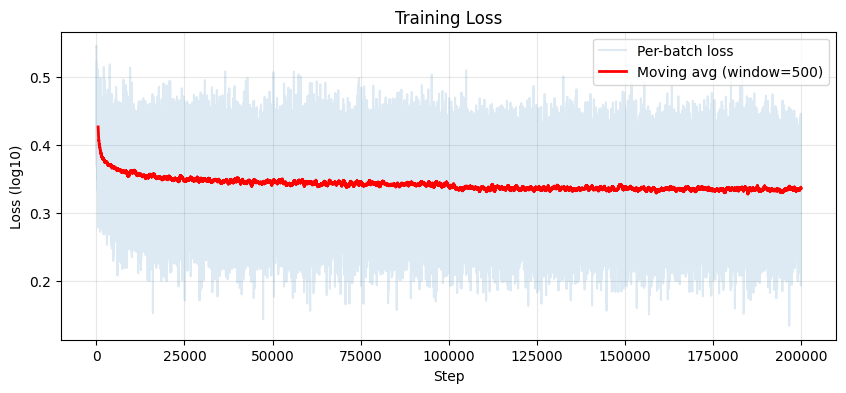

In [93]:
def plot_loss(lossi):
    # Plot training loss over time
    plt.figure(figsize=(10, 4))
    stepi = list(range(len(lossi)))
    plt.plot(stepi, lossi, alpha=0.15, color='tab:blue', label='Per-batch loss')

    # Moving average (window of 500 steps) to show the trend clearly
    window = 500
    moving_avg = torch.tensor(lossi).unfold(0, window, 1).mean(dim=1)
    plt.plot(stepi[window-1:], moving_avg, color='red', linewidth=2, label=f'Moving avg (window={window})')

    plt.xlabel('Step')
    plt.ylabel('Loss (log10)')
    plt.title('Training Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_loss(lossi)

In [94]:
# calculate the batchnorm statistics since we did not keep track of running mean and avg

with torch.no_grad():
    emb = C[Xtr]
    emb_cat = emb.view(emb.shape[0], -1)

    hpreact = emb_cat @ W1 + b1

    # measure mean and std
    bnmean = hpreact.mean(axis=0, keepdim=True)
    bnstd = hpreact.std(axis=0, keepdim=True)


In [95]:
# now we can use these during our evaluation/inference
@torch.no_grad()
def eval_loss(X, Y, params):
    C, W1, b1, W2, b2, bngain, bnbias = params

    emb = C[X]
    emb_cat = emb.view(emb.shape[0], -1)

    hpreact = emb_cat @ W1 + b1
    hpreact = (hpreact - bnmean) / bnstd
    hpreact = hpreact*bngain + bnbias

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    return loss.item()

train_loss = eval_loss(Xtr, Ytr, parameters)
val_loss = eval_loss(Xdev, Ydev, parameters)

print(f"{train_loss = }")
print(f"{val_loss = }")

train_loss = 2.1479952335357666
val_loss = 2.164593458175659


In [96]:
# Sample from the model (using precomputed bnmean/bnstd from above)
g_sample = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]                             # (1, block_size, embed_dim)
        embcat = emb.view(1, -1)
        hprebn = embcat @ W1 + b1
        hpreact = (hprebn - bnmean) / bnstd                         # normalize using training set stats
        hpreact = hpreact * bngain + bnbias
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g_sample).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carlah.
amelle.
khi.
mili.
taty.
sacassa.
jazhutefaresyn.
jarqui.
ner.
kiah.
maiivon.
leigh.
ham.
join.
quinn.
shon.
rai.
adbi.
watell.
dearyxi.


# Summary and Key Takeaways

In this notebook we manually implemented the entire backward pass of a character-level language model — no `loss.backward()` required. Here's what we covered across the four exercises:

## Exercise 1: Atomic Backpropagation

We broke the forward pass into its smallest possible operations and derived the gradient through each one individually. This gave us a set of **reusable rules** for common operations:

| Rule                 | Operation                 | Backward Pass                                         |
| -------------------- | ------------------------- | ----------------------------------------------------- |
| Linear layer input   | $Y = X @ W + b$           | $dX = dY @ W^T$                                       |
| Linear layer weights | $Y = X @ W + b$           | $dW = X^T @ dY$                                       |
| Linear layer bias    | $Y = X @ W + b$           | $db = dY.\text{sum}(\text{axis}=0)$                   |
| Element-wise op      | $Y = f(X)$                | $dX = dY \cdot f'(X)$                                 |
| Broadcast multiply   | $Y = A * B$ (B broadcast) | $dB = (dY \cdot A).\text{sum}(\text{broadcast axis})$ |
| Selection/indexing   | $Y = X[\text{indices}]$   | Scatter-add $dY$ back to the selected positions       |
| Multi-use variable   | $X$ used in two ops       | $dX = dX_1 + dX_2$ (sum the contributions)            |

The key insight: **every backward rule is mechanical** — once you know the forward operation, the backward pass follows directly.

## Exercise 2: Fused Cross-Entropy Backward

Instead of backpropagating through `logits → norm_logits → counts → counts_sum → probs → logprobs → loss` (7 steps, 10+ gradient lines), we derived the gradient in one shot:

$$\frac{\partial L}{\partial \text{logits}_i} = \frac{1}{n}(P_i - \mathbb{1}_{i = y})$$

where $P_i$ is the softmax probability. This is what `F.cross_entropy` computes internally — and it's both simpler and more numerically stable than the atomic version.

## Exercise 3: Fused Batchnorm Backward

Similarly, instead of backpropagating through 7 intermediate batchnorm variables, we derived a single fused expression:

$$\frac{\partial L}{\partial x_i} = \frac{\gamma(\sigma^2 + \epsilon)^{-1/2}}{m} \left[ m \frac{\partial L}{\partial y_i} - \sum_j \frac{\partial L}{\partial y_j} - \frac{m}{m-1} \hat{x}_i \sum_j \frac{\partial L}{\partial y_j} \hat{x}_j \right]$$

The derivation required careful tracking of **cross-sample dependencies** — batchnorm is unusual because $\mu$ and $\sigma^2$ couple all samples in the batch. We also saw a beautiful cancellation where $\frac{\partial \sigma^2}{\partial \mu} = 0$ because $\sum(x_i - \mu) = 0$ by definition.

## Exercise 4: Full Manual Training

We put it all together into a complete training loop with **zero calls to `loss.backward()`** — every gradient computed by hand. The model trained to the same loss as the autograd version, confirming our derivations are correct.

## The Bigger Picture

This exercise builds the intuition that **backpropagation is not magic** — it's just the chain rule applied systematically. Every operation in the forward pass has a local gradient, and we multiply and accumulate these local gradients going backwards. Understanding this at a low level is valuable because:

1. **Debugging** — when gradients explode, vanish, or are just wrong, you can reason about _where_ in the chain the problem originates
2. **Custom operations** — if you need a custom backward pass (e.g. for efficiency or for a novel operation), you know exactly how to derive one
3. **Fused kernels** — the fused cross-entropy and batchnorm backwards show that combining multiple steps into one can be both simpler and faster — this is exactly what PyTorch and frameworks like FlashAttention do under the hood
4. **Appreciation for autograd** — after doing this by hand, you'll never take `loss.backward()` for granted again!

<br>

> Thanks to the Andrej, we can now call ourselves _backprop ninjas_!

![Hyaah!](backprop_ninja.png)
